In [9]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,turn_direction,turn_to_obstacle,zero_out_angle
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def distance_at_head_turn_2(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,12))
        if len(peaks) == 0:
            df.at[ind,'distance_at_head_turn_2'] = np.nan
            df.at[ind,'angle_at_head_turn_2'] = np.nan
            df.at[ind,'num_turn'] = 0
        else:
            max_peak = peaks[prop['peak_heights'].argmax()]
  
            df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_at_head_turn_2_index'] = max_peak
            df.at[ind,'angle_at_head_turn_2'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'num_turn'] = len(peaks)

In [5]:
def wall_obstacle(df):
    condition_dict = {'blackblack': ['black','black'], 'whiteblack': ['white','black'],'whitenoise':['white','noise'],
                  'blackwhite':['black','white'], 'noisewhite':['noise','white'], 'noisenoise':['noise','noise'],
                  'blacknoise':['black','noise'], 'whitewhite':['white','white'],'whtewhite':['white','white'],'noiseblack':['noise','black']}
    
    for ind, row in df.iterrows():
        for key in condition_dict.keys():
            if key == row.condition:
                df.at[ind,'wall'] = condition_dict.get(key)[0]
                df.at[ind,'obstacle'] = condition_dict.get(key)[1]

In [212]:
oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_G8CK_oa_con1.json",'blank')
oa_session.gather_session_df('obstacle',6)
con_new = oa_session.df

6


In [213]:
distance_calcs(con_new)
heading_calcs(con_new)
deveation(con_new)
get_head_angle(con_new)
head_angle_velocity(con_new)
turn_direction(con_new)
turn_to_obstacle(con_new)
con_new = drop_nans_in_columns(con_new,'obstacle_ind')
distance_at_head_turn_2(con_new)
lateral_error(con_new)
wall_obstacle(con_new)
con_new_long_nostart,con_new_short_nostart,con_new_middle_nostart = create_df_by_type_nostart(con_new)

corner
port


In [319]:
con_new.loc[(con_new.wall == 'black')&(con_new.date == '071623'),'date']='071723'
con_new_long_nostart,con_new_short_nostart,con_new_middle_nostart = create_df_by_type_nostart(con_new)

In [107]:
oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_G8CK_oa_con_090523.json",'blank')
oa_session.gather_session_df('obstacle',6)
oa_090523 = oa_session.df
distance_calcs(oa_090523)
heading_calcs(oa_090523)
deveation(oa_090523)
get_head_angle(oa_090523)
head_angle_velocity(oa_090523)
turn_direction(oa_090523)
turn_to_obstacle(oa_090523)
oa_090523 = drop_nans_in_columns(oa_090523,'obstacle_ind')
distance_at_head_turn_2(oa_090523)
lateral_error(oa_090523)
wall_obstacle(oa_090523)
oa_090523_long_nostart,oa_090523_short_nostart,oa_090523_middle_nostart = create_df_by_type_nostart(oa_090523)

6
corner
port


In [329]:
con_new_long_nostart.date.unique()

array(['071523', '071623', '071723', '071823', '071923', '072023',
       '072123', '072323', '072523', '072623', '072823', '073123',
       '080423', '081523', '082123', '082923', '082823'], dtype=object)

In [6]:
con0 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\compiled_data\h5\conditions0.h5")
distance_calcs(con0)
heading_calcs(con0)
deveation(con0)
get_head_angle(con0)
head_angle_velocity(con0)
turn_direction(con0)
turn_to_obstacle(con0)
con0 = drop_nans_in_columns(con0,'obstacle_ind')
distance_at_head_turn_2(con0)
lateral_error(con0)
wall_obstacle(con0)
con0_long_nostart,con0_short_nostart,con0_middle_nostart = create_df_by_type_nostart(con0)

corner
port


In [7]:
con1 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\compiled_data\h5\conditions1.h5")
distance_calcs(con1)
heading_calcs(con1)
deveation(con1)
get_head_angle(con1)
head_angle_velocity(con1)
turn_direction(con1)
turn_to_obstacle(con1)
con1 = drop_nans_in_columns(con1,'obstacle_ind')
distance_at_head_turn_2(con1)
lateral_error(con1)
wall_obstacle(con1)
con1_long_nostart,con1_short_nostart,con1_middle_nostart = create_df_by_type_nostart(con1)

corner
port


In [8]:
con2 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\compiled_data\h5\conditions2.h5")
distance_calcs(con2)
heading_calcs(con2)
deveation(con2)
get_head_angle(con2)
head_angle_velocity(con2)
turn_direction(con2)
turn_to_obstacle(con2)
con2 = drop_nans_in_columns(con2,'obstacle_ind')
distance_at_head_turn_2(con2)
lateral_error(con2)
wall_obstacle(con2)
con2_long_nostart,con2_short_nostart,con2_middle_nostart = create_df_by_type_nostart(con2)


corner
port


In [108]:
con = pd.concat([con0,con1,con2,oa_090523])
wall_obstacle(con)
con_long_nostart,con_short_nostart,con_middle_nostart = create_df_by_type_nostart(con)


In [32]:
def wall_obstacle(df):
    condition_dict = {'blackblack': ['black','black'], 'whiteblack': ['white','black'],'whitenoise':['white','noise'],
                  'blackwhite':['black','white'], 'noisewhite':['noise','white'], 'noisenoise':['noise','noise'],
                  'blacknoise':['black','noise'], 'whitewhite':['white','white'],'whtewhite':['white','white'],'noiseblack':['noise','black']}
    
    for ind, row in df.iterrows():
        for key in condition_dict.keys():
            if key == row.condition:
                df.at[ind,'wall'] = condition_dict.get(key)[0]
                df.at[ind,'obstacle'] = condition_dict.get(key)[1]

Text(0.5, 0.98, 'obstacle')

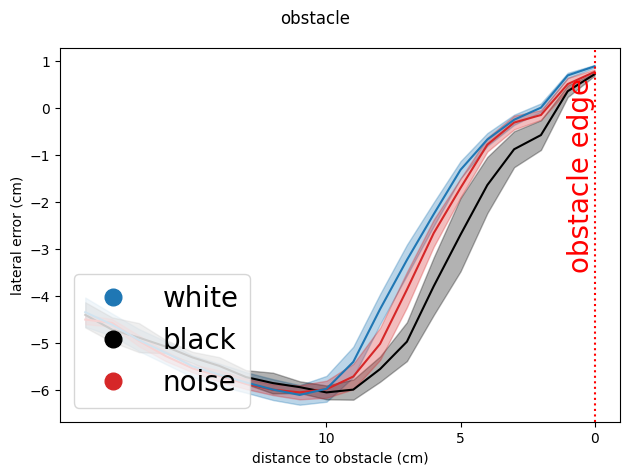

In [270]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['wall']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['date']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.wall.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='top', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

Text(0.5, 0.98, 'obstacle')

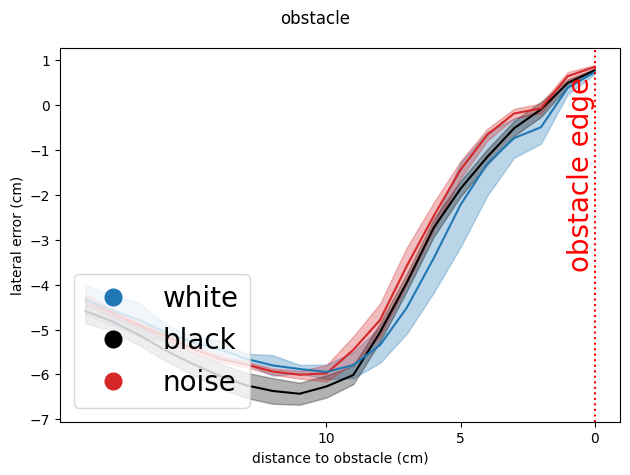

In [269]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['obstacle']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['date']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.obstacle.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='top', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

Text(0.5, 0.98, 'wall')

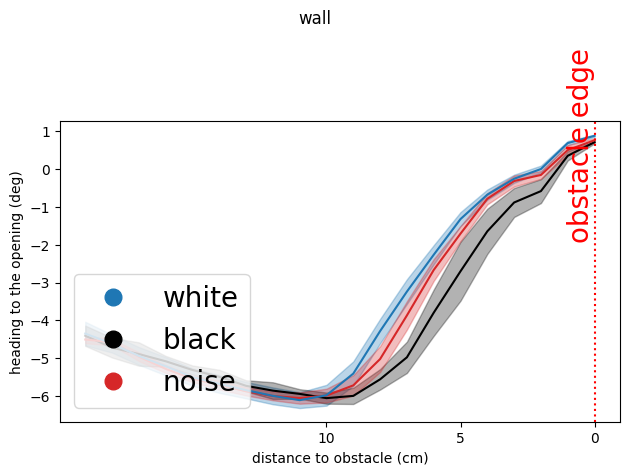

In [229]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['wall']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['date']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.wall.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('wall')

In [ ]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con0_long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['obstacle']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.obstacle.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

Text(0.5, 0.98, 'obstacle')

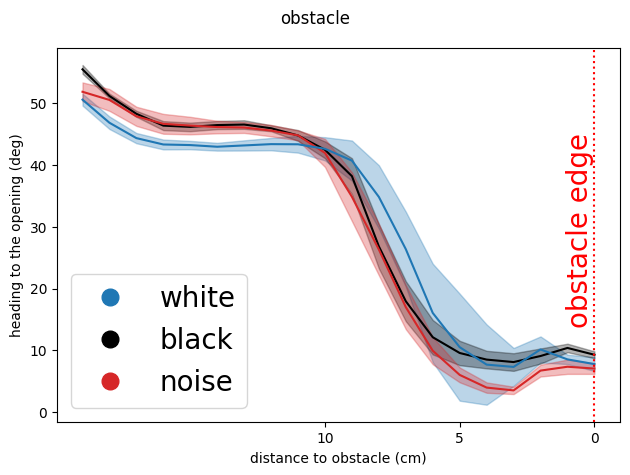

In [221]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])
white = data[data.obstacle == 'white']
black = data[data.obstacle == 'black']
noise = data[data.obstacle == 'noise']
data= pd.concat([white,black,noise])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['obstacle']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['date']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.obstacle.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

In [249]:
con_new_long_nostart.groupby(['obstacle']).linearity.notna.mean()

AttributeError: 'SeriesGroupBy' object has no attribute 'notna'

In [246]:
con_new_long_nostart.groupby(['wall']).linearity.mean()

wall
black    0.796811
noise    0.859343
white    0.882733
Name: linearity, dtype: float64

In [56]:
 data[data.obstacle == 'white'].animal.unique()

array(['G8CK1RT', 'G8CK1LT', 'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT',
       'G8CKTT', 'G8CKRN', 'G8CKLN'], dtype=object)

In [84]:
con_long_nostart.date.unique()

array(['071523', '071623', '071723', '071823', '071923', '072023',
       '072123', '072323', '072523', '072623', '072823', '073123',
       '080123', '080223', '080423', '080923', '081023', '081123',
       '081523'], dtype=object)

In [ ]:
con_long_nostart[con_long_nostart.date == '']

274
9
253
9
234
9
242
9


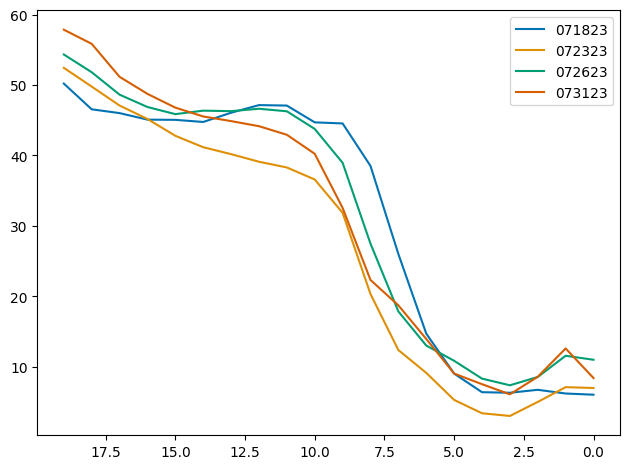

In [196]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.wall == 'noise']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
color_dict = create_color_dict(data,'date','colorblind',sort=False)

for ob,ob_df in  data.groupby(['date']):
    print(len(ob_df))
    print(len(ob_df.animal.unique()))
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)
    ax.legend(color_dict)


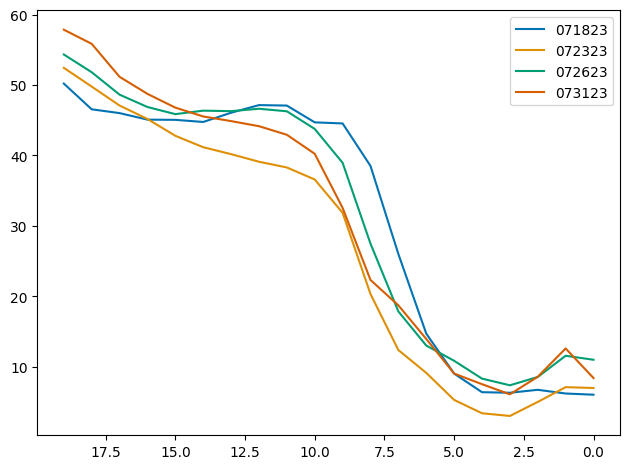

In [206]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
data = data[data.wall == 'noise']
color_dict = create_color_dict(data,'date','colorblind',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['date']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

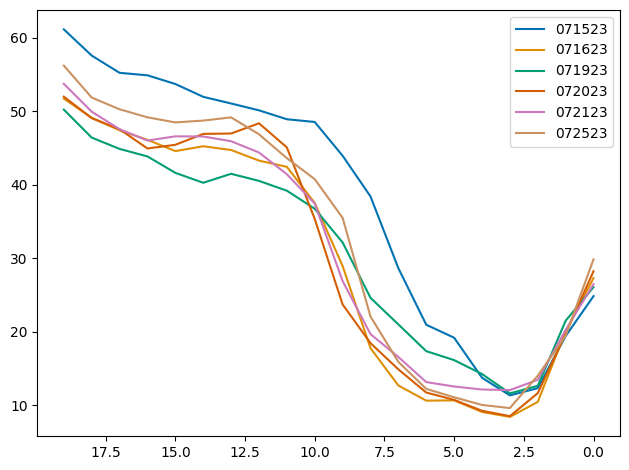

In [264]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
data = data[data.wall == 'white']
color_dict = create_color_dict(data,'date','colorblind',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['date']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

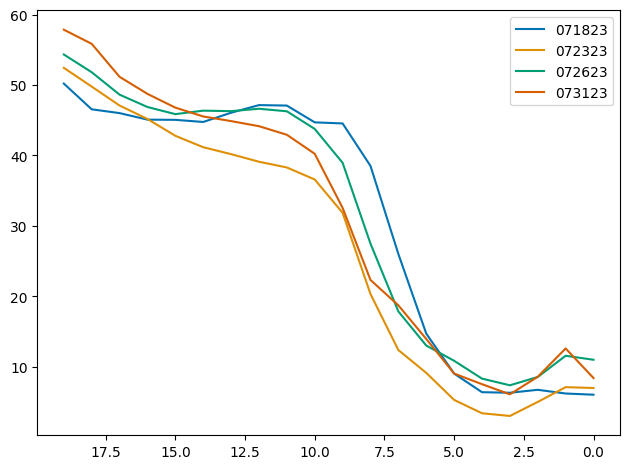

In [256]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
data = data[data.wall == 'noise']
color_dict = create_color_dict(data,'date','colorblind',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['date']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

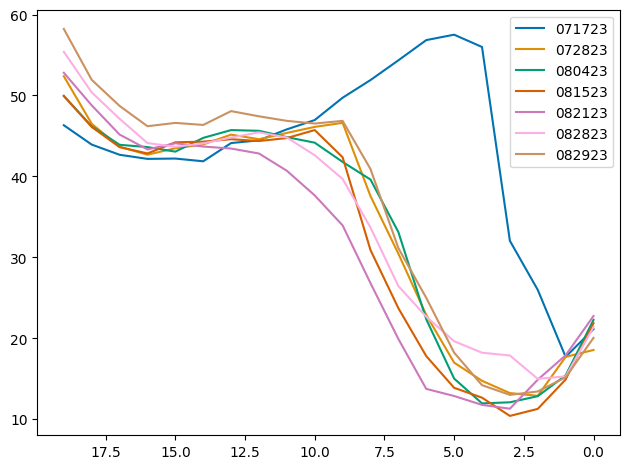

In [266]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.date != '071623']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
data = data[data.wall == 'black']
color_dict = create_color_dict(data,'date','colorblind',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['date']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

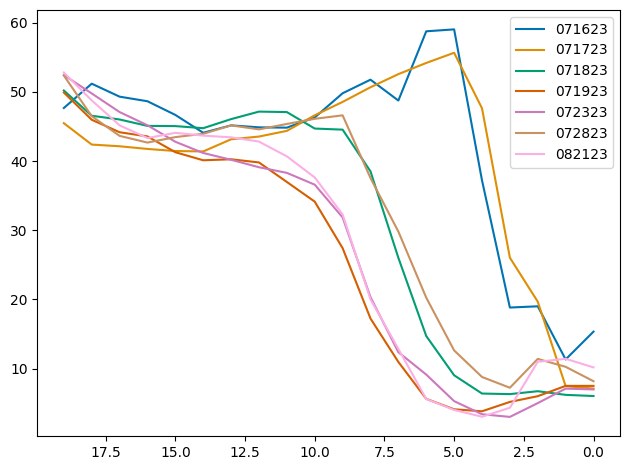

In [261]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
data = data[data.obstacle == 'white']
color_dict = create_color_dict(data,'date','colorblind',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['date']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

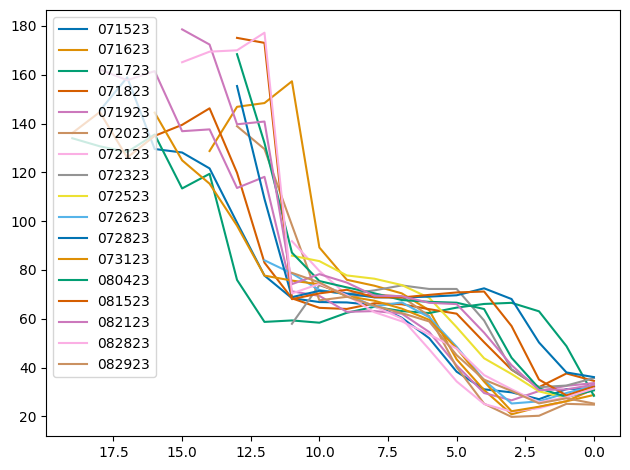

In [356]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_short_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
#data = data[data.wall == 'noise']
color_dict = create_color_dict(data,'date','colorblind',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['date']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

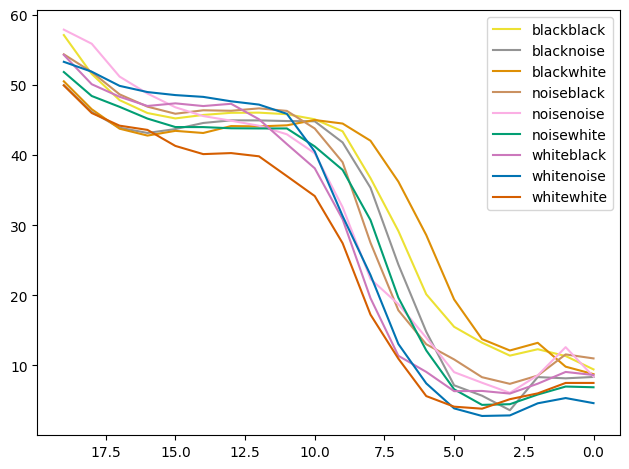

In [322]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)

color_dict = create_color_dict(data,'condition','colorblind',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['condition']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

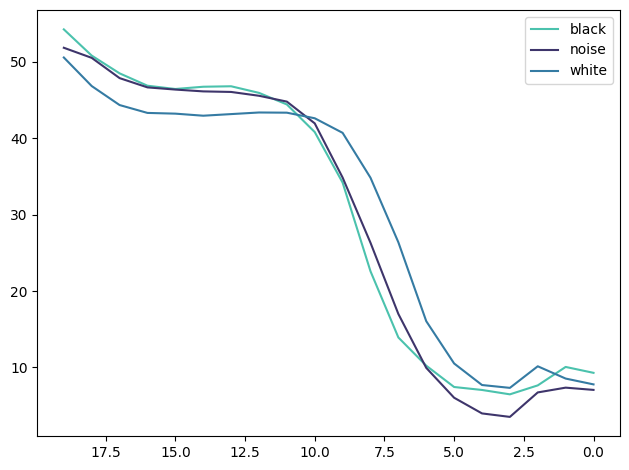

In [208]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
color_dict = create_color_dict(data,'obstacle','mako',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['obstacle']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

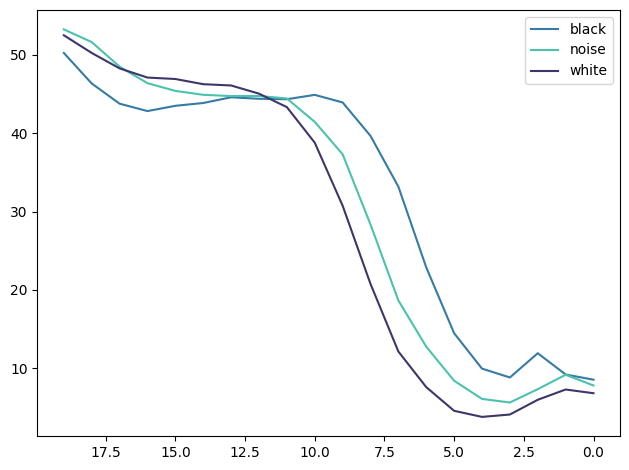

In [207]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.wall == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
color_dict = create_color_dict(data,'wall','mako',sort=False)
ob_label = []
for ob,ob_df in data.groupby(['wall']):
    ob_label.append(ob)
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
    
    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)

    ax.legend(ob_label)

 
  
    
    

Text(0.5, 0, '')

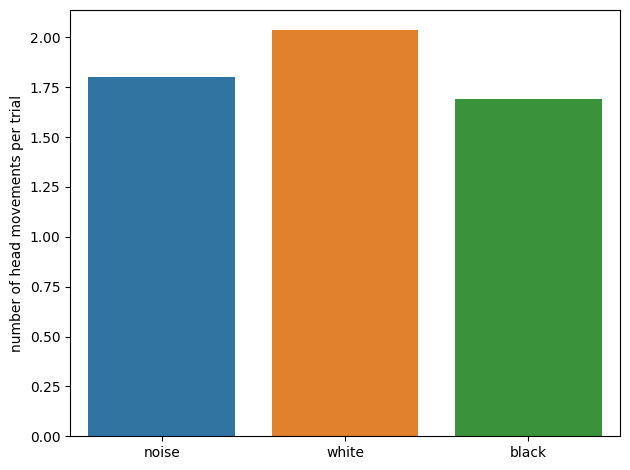

In [245]:
fig,ax = plt.subplots(layout = 'tight')
data = con_new_long_nostart
data = data.drop(columns=['level_0'])
data = data.reset_index()
data = data[data.num_turn<=10]
data = data[data.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='obstacle' ,y = 'num_turn',hue = 'obstacle',estimator = 'mean',ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')

Text(0.5, 0, '')

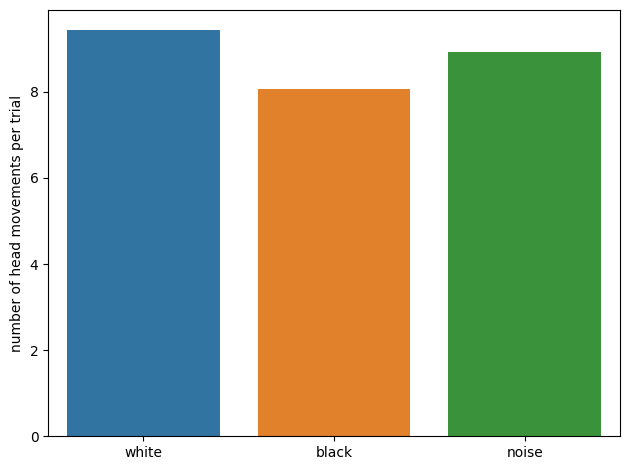

In [243]:
fig,ax = plt.subplots(layout = 'tight')
data = con_new_long_nostart
data = data.drop(columns=['level_0'])
data = data.reset_index()
data = data[data.num_turn<=10]
data = data[data.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='wall' ,y = 'distance_at_head_turn_2',hue = 'wall',estimator = 'median',ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')

Text(0.5, 0, '')

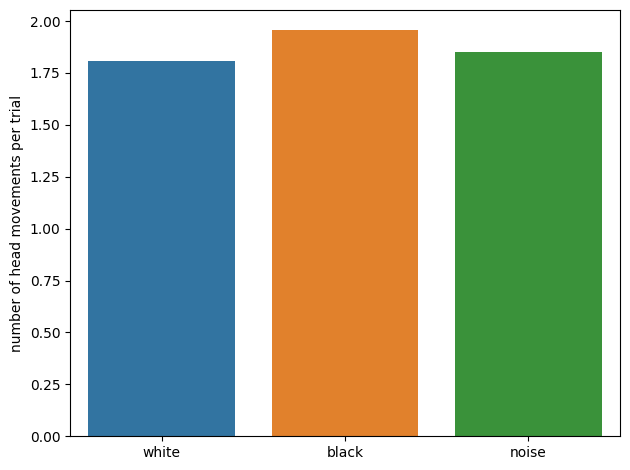

In [238]:
fig,ax = plt.subplots(layout = 'tight')
data = con_new_long_nostart
data = data.drop(columns=['level_0'])
data = data.reset_index()
data = data[data.num_turn<=10]
data = data[data.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='wall' ,y = 'num_turn',hue = 'wall',estimator = 'mean',ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')

Text(0.5, 0, '')

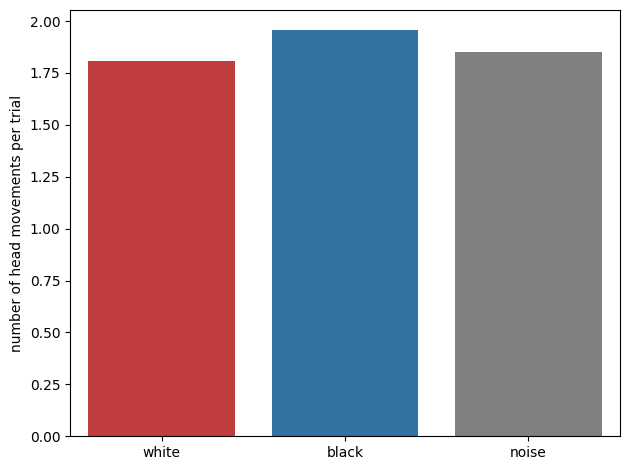

In [323]:
fig,ax = plt.subplots(layout = 'tight')
data = con_new_long_nostart
data = data.drop(columns=['level_0'])
data = data.reset_index()
data = data[data.num_turn<=10]
data = data[data.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='wall' ,y = 'num_turn',hue = 'wall',estimator = 'mean',palette=['tab:red','tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')
#ax.set_xticks([0,1],['light','mon'])


#light = data[data.task == 'oa']
#light_mean = light.num_turn.mean()
#light_after= np.nanstd(light.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).num_turn.mean().to_numpy()))

#dark = data[data.task_com == 'mon']
#dark_mean = dark.num_turn.mean()
#dark_after= np.nanstd(dark.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).num_turn.mean().to_numpy()))

#ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

In [325]:
con_new_long_nostart[(con_new_long_nostart.wall == 'noise')].groupby(['date']).num_turn.mean()

date
071823    2.607656
072323    1.545012
072623    1.382629
073123    1.431707
Name: num_turn, dtype: float64

In [324]:
con_new_long_nostart[(con_new_long_nostart.wall == 'white')].groupby(['date']).num_turn.mean()

date
071523    2.095541
071623    2.018041
071923    1.862197
072023    1.334842
072123    1.473538
072523    1.474654
Name: num_turn, dtype: float64

In [347]:
df_tortuosity(con_new_long_nostart)

Text(0.5, 1.0, 'black wall')

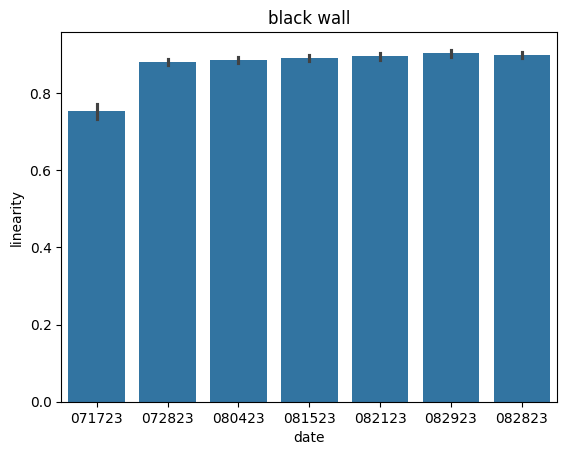

In [348]:
sns.barplot(data = con_new_long_nostart[(con_new_long_nostart.wall == 'black')],x = 'date',y ='linearity')
plt.title('black wall')

Text(0.5, 1.0, 'black wall')

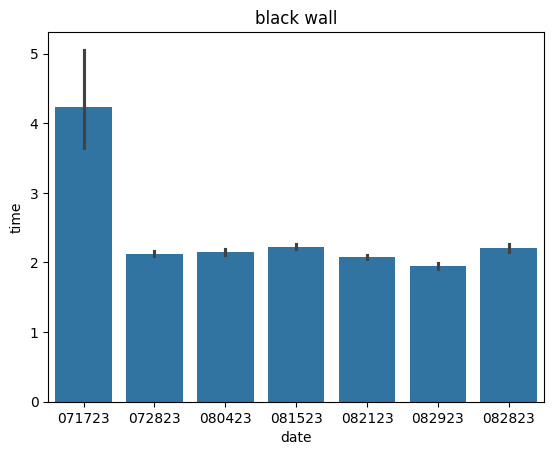

In [345]:
sns.barplot(data = con_new_long_nostart[(con_new_long_nostart.wall == 'black')],x = 'date',y ='time')
plt.title('black wall')

Text(0.5, 1.0, 'black wall')

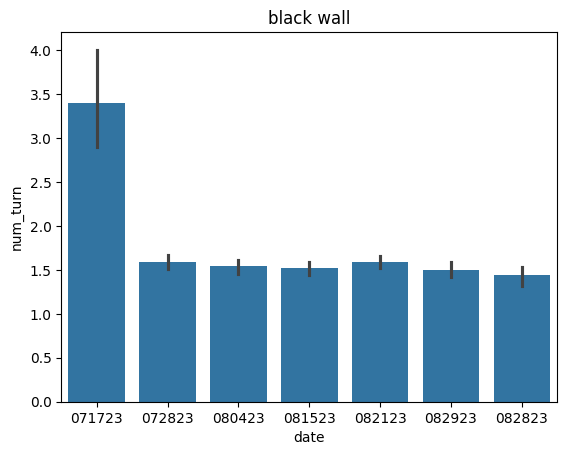

In [340]:
sns.barplot(data = con_new_long_nostart[(con_new_long_nostart.wall == 'black')],x = 'date',y ='num_turn')
plt.title('black wall')

Text(0.5, 1.0, 'white wall')

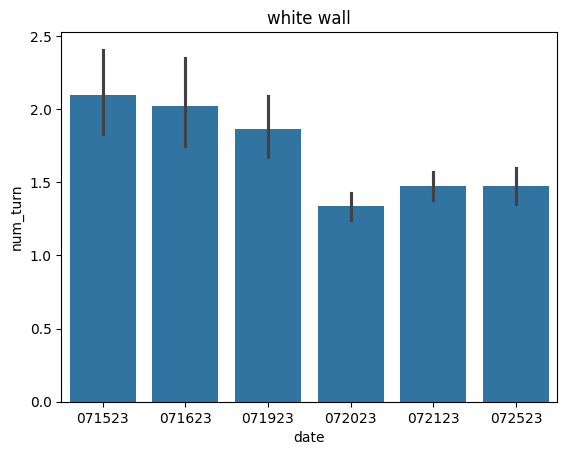

In [341]:
sns.barplot(data = con_new_long_nostart[(con_new_long_nostart.wall == 'white')],x = 'date',y ='num_turn')
plt.title('white wall')

Text(0.5, 1.0, 'noise wall')

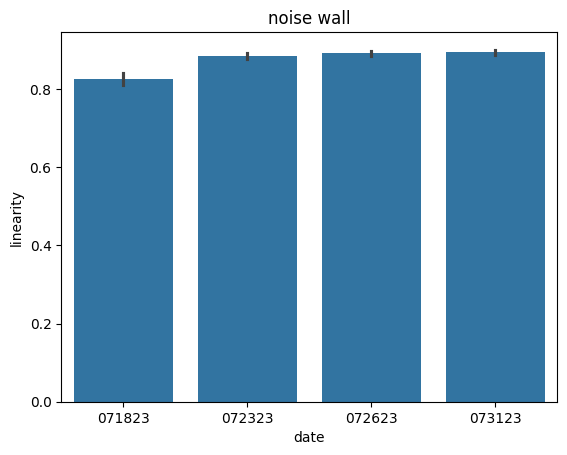

In [351]:
sns.barplot(data = con_new_long_nostart[(con_new_long_nostart.wall == 'noise')],x = 'date',y ='linearity')
plt.title('noise wall')

Text(0.5, 1.0, 'white wall')

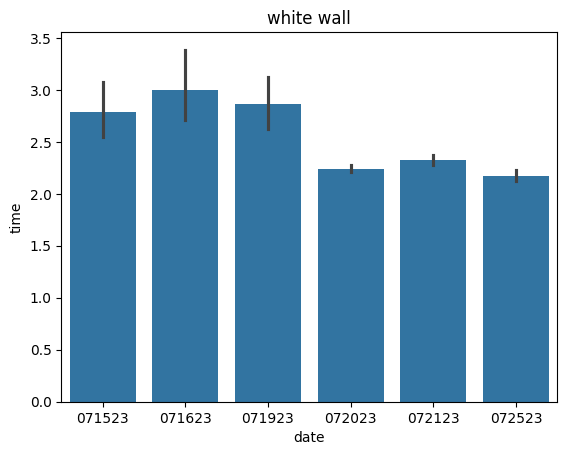

In [352]:
sns.barplot(data = con_new_long_nostart[(con_new_long_nostart.wall == 'white')],x = 'date',y ='time')
plt.title('white wall')

Text(0.5, 1.0, 'white wall')

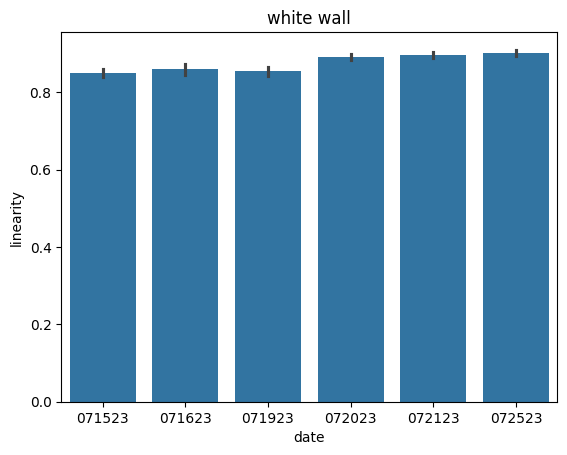

In [349]:
sns.barplot(data = con_new_long_nostart[(con_new_long_nostart.wall == 'white')],x = 'date',y ='linearity')
plt.title('white wall')

Text(0.5, 1.0, 'white wall')

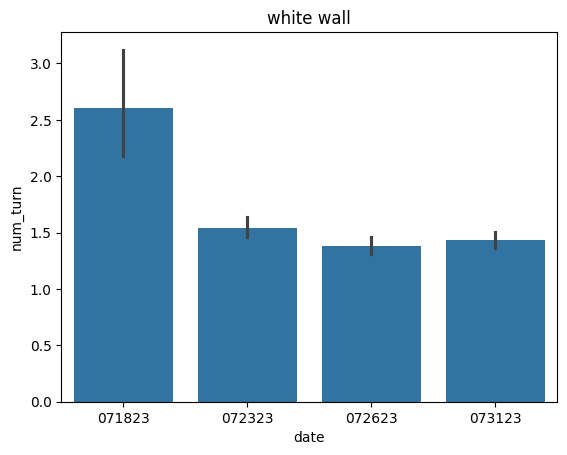

In [342]:
sns.barplot(data = con_new_long_nostart[(con_new_long_nostart.wall == 'noise')],x = 'date',y ='num_turn')
plt.title('white wall')

In [ ]:
con_new_long_nostart[(con_new_long_nostart.wall == 'black')].groupby(['date']).num_turn

In [93]:
con_long_nostart[con_long_nostart.condition == 'blackwhite'].date.unique()

array(['071723', '072823'], dtype=object)

66
1
60
1
66
1
44
1
37
1
61
1
53
1
50
1
86
1


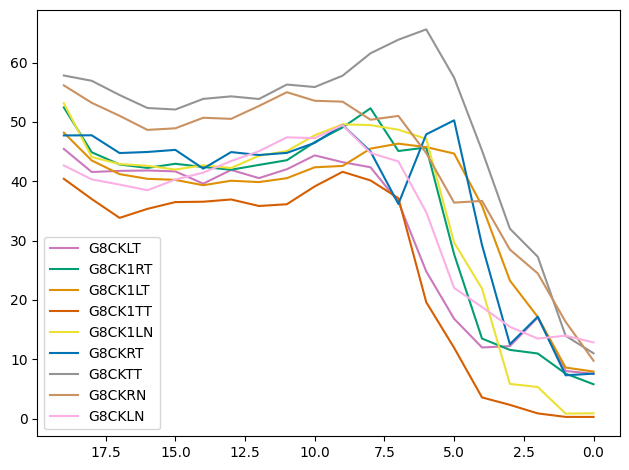

In [168]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = con_new_long_nostart[con_new_long_nostart.wall == 'black']



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
color_dict = create_color_dict(data,'animal','colorblind',sort=False)

for ob,ob_df in  data.groupby(['animal']):
    print(len(ob_df))
    print(len(ob_df.animal.unique()))
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)
    ax.legend(color_dict)


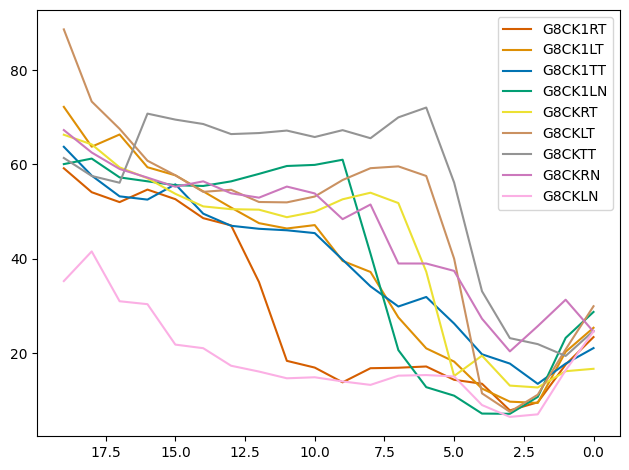

In [368]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = con_new_long_nostart



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.date == '071523']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
color_dict = create_color_dict(data,'animal','colorblind',sort=False)

for ob,ob_df in  data.groupby(['animal']):
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)
    ax.legend(color_dict)

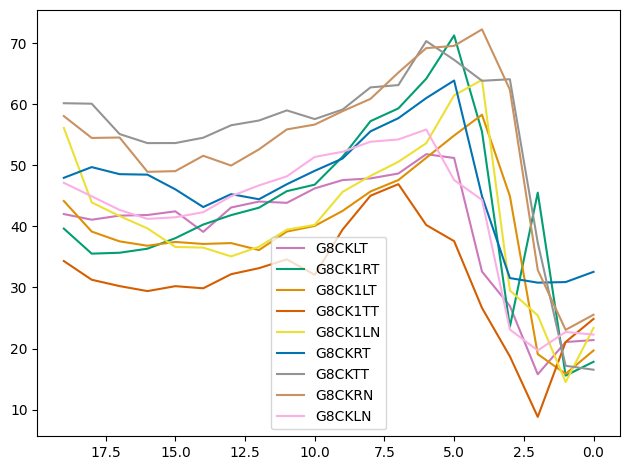

In [367]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = con_new_long_nostart



data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.date == '071723']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
color_dict = create_color_dict(data,'animal','colorblind',sort=False)

for ob,ob_df in  data.groupby(['animal']):
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)
    ax.legend(color_dict)

34
1
143
4
340
9
400
9
356
9
380
9
437
9


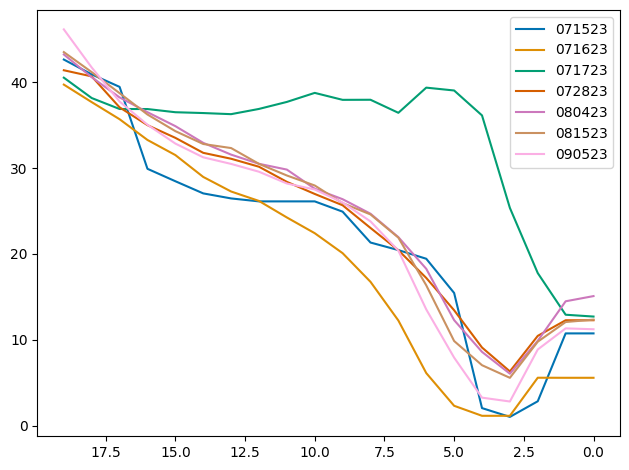

In [328]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = con_long_nostart[con_long_nostart.wall == 'black']



data = drop_nans_in_columns(data,'obstacle_ind')
#data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
color_dict = create_color_dict(data,'date','colorblind',sort=False)

for ob,ob_df in  data.groupby(['date']):
    print(len(ob_df))
    print(len(ob_df.animal.unique()))
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)
    ax.legend(color_dict)

Text(0.5, 0.98, 'wall')

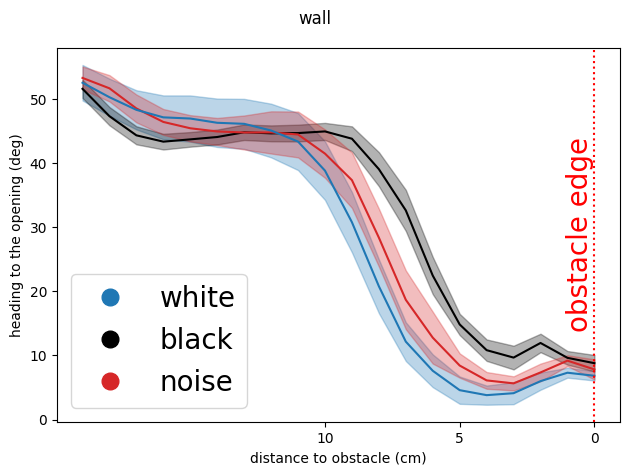

In [278]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])

data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['wall']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.wall.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('wall')

Text(0.5, 0.98, 'wall')

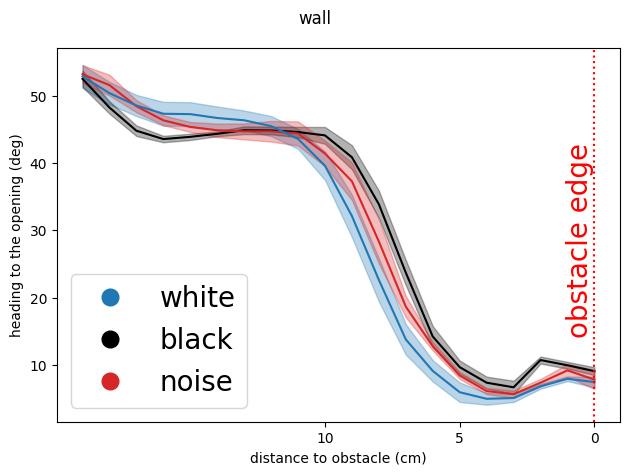

In [276]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])

data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.date != '071723']
data = data[data.date != '071623']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['wall']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['date']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.wall.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('wall')

Text(0.5, 0.98, 'wall')

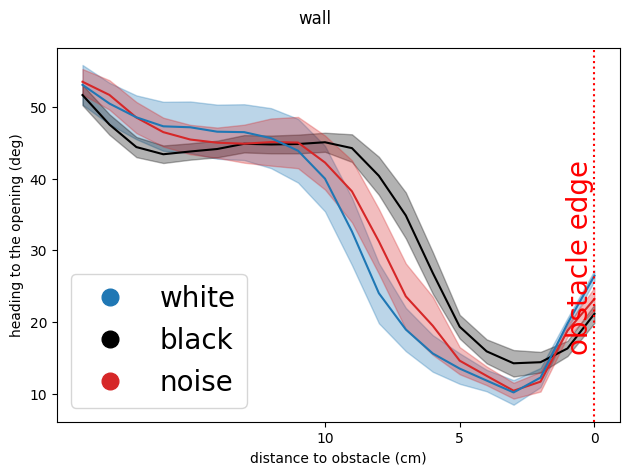

In [259]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])
#white = data[data.obstacle == 'white'].sample(300)
#black = data[data.obstacle == 'black'].sample(300)
#noise = data[data.obstacle == 'noise'].sample(300)
#data= pd.concat([white,black,noise])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['wall']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.wall.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('wall')

Text(0.5, 0.98, 'obstacle')

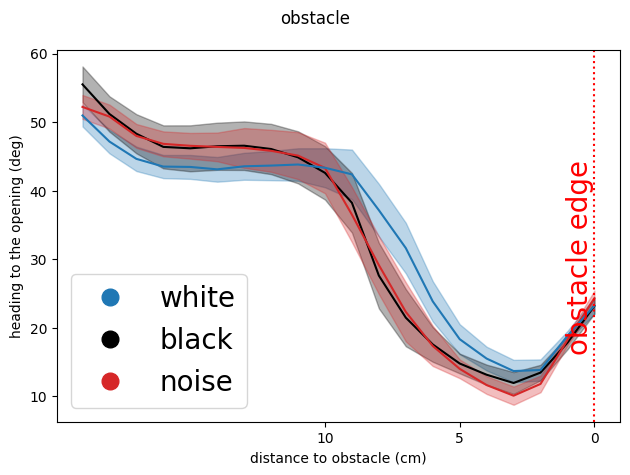

In [280]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['obstacle']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.obstacle.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

Text(0.5, 0.98, 'obstacle')

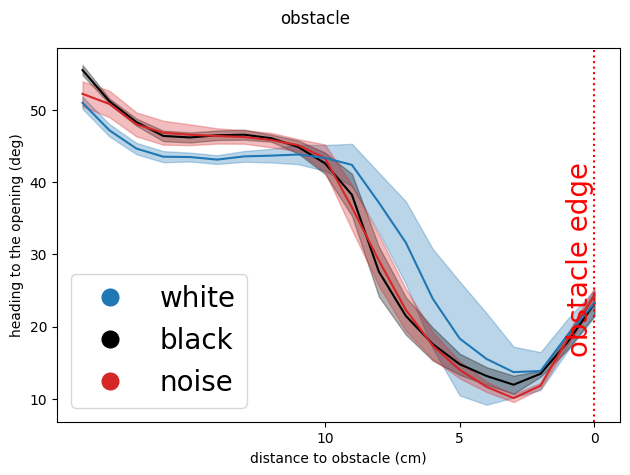

In [281]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_new_long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['obstacle']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['date']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.obstacle.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

ValueError: Cannot take a larger sample than population when 'replace=False'

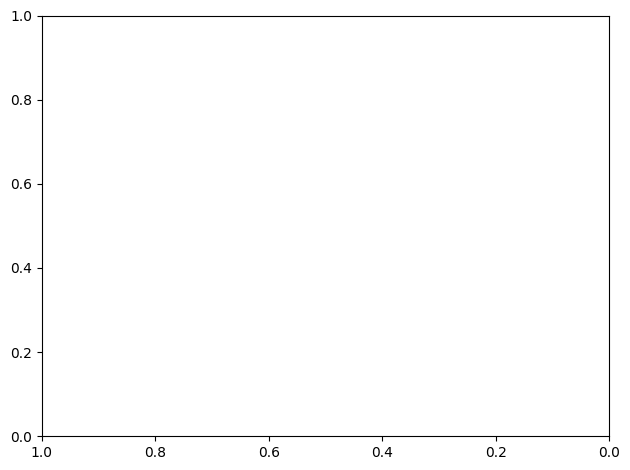

In [154]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con2_long_nostart])
white = data[data.obstacle == 'white'].sample(300)
black = data[data.obstacle == 'black'].sample(300)
noise = data[data.obstacle == 'noise'].sample(300)
data= pd.concat([white,black,noise])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['obstacle']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.obstacle.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

Text(0.5, 0.98, 'obstacle')

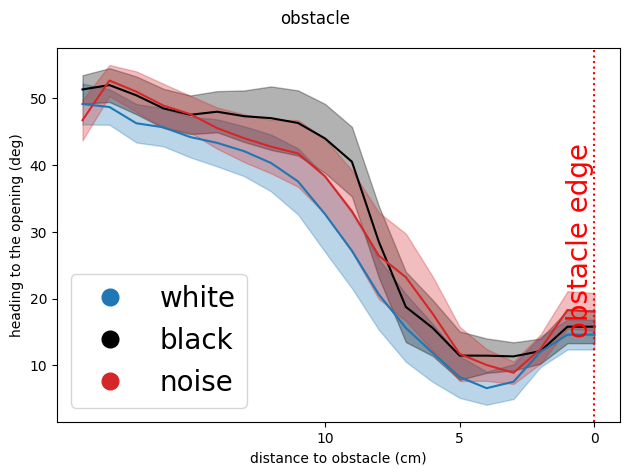

In [147]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con1_long_nostart])
white = data[data.obstacle == 'white'].sample(300)
black = data[data.obstacle == 'black'].sample(300)
noise = data[data.obstacle == 'noise'].sample(300)
data= pd.concat([white,black,noise])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['obstacle']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.obstacle.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

Text(0.5, 0.98, 'obstacle')

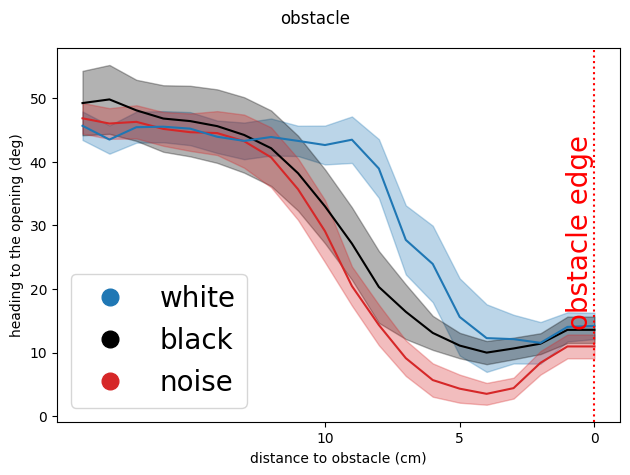

In [143]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con0_long_nostart])
white = data[data.obstacle == 'white'].sample(300)
black = data[data.obstacle == 'black'].sample(300)
noise = data[data.obstacle == 'noise'].sample(300)
data= pd.concat([white,black,noise])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['obstacle']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.obstacle.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.obstacle.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('obstacle')

In [96]:
con0.date.unique()

array(['071523', '071623', '071723', '071823', '071923', '072023',
       '072123', '072323'], dtype=object)

In [100]:
con0[con0.date == '071623'].animal.unique()

array(['G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'], dtype=object)

Text(0.5, 0, '')

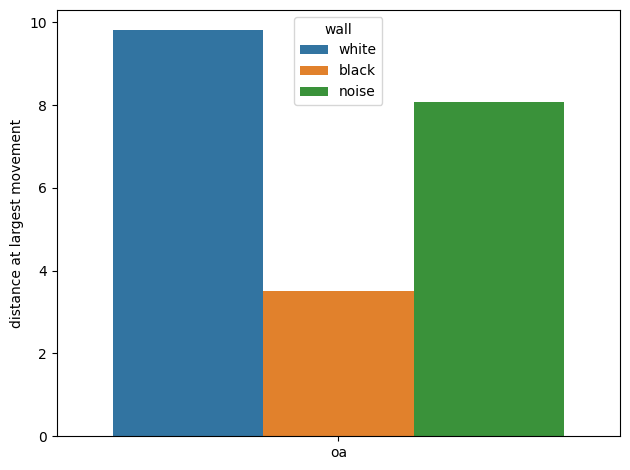

In [92]:
fig,ax = plt.subplots(layout = 'tight')
data = con0_long_nostart[con0_long_nostart.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn_2',hue = 'wall',estimator = 'median',ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('distance at largest movement')
ax.set_xlabel('')


Text(0.5, 0, '')

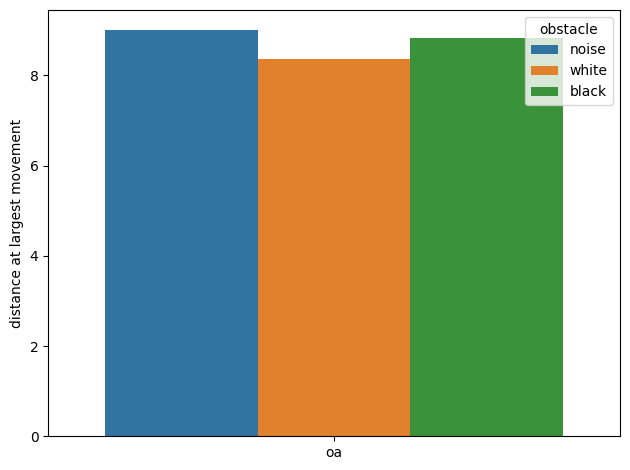

In [232]:
fig,ax = plt.subplots(layout = 'tight')
data = con_new_long_nostart[con_new_long_nostart.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn_2',hue = 'obstacle',estimator = 'median',ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('distance at largest movement')
ax.set_xlabel('')


Text(0.5, 0, '')

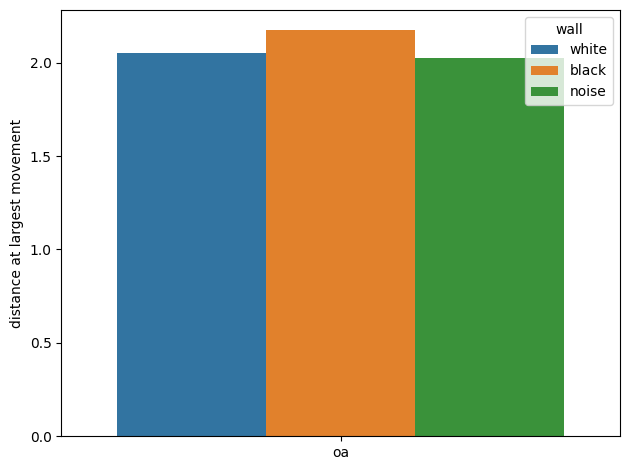

In [234]:
fig,ax = plt.subplots(layout = 'tight')
data = con_new_long_nostart[con_new_long_nostart.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'num_turn',hue = 'wall',estimator = 'mean',ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('distance at largest movement')
ax.set_xlabel('')


Text(0.5, 0.98, 'wall')

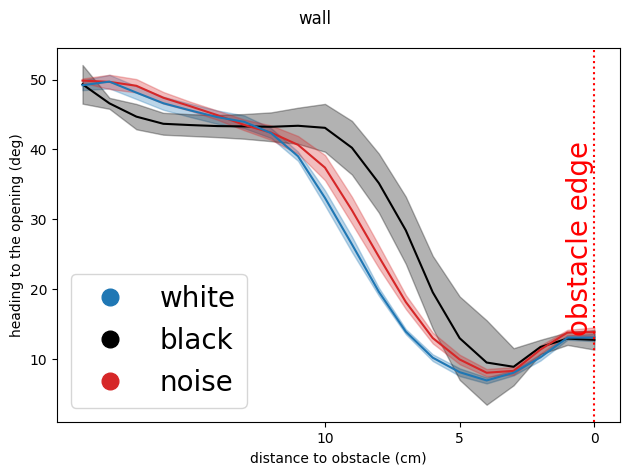

In [218]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['wall']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['date']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.wall.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('wall')

Text(0.5, 0.98, 'wall')

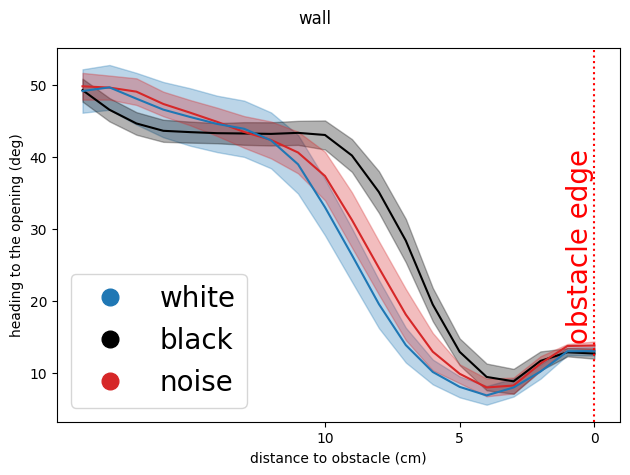

In [223]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([con_long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
white_medians = []
black_medians = []
noise_medians = []
white_sd = []
black_sd = []
noise_sd = []
for ob,ob_df in  data.groupby(['wall']):
  
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if ob == 'white':
        white_array = angle_array
        white_angle_median= np.nanmedian(white_array,axis = 0)
        ax.plot(xnew,white_angle_median,c = 'tab:blue',alpha = 1)
    elif ob == 'black':
        black_array = angle_array
        black_angle_median= np.nanmedian(black_array,axis = 0)
        ax.plot(xnew,black_angle_median,c = 'black',alpha = 1)
    elif ob == 'noise':
        noise_array = angle_array
        noise_angle_median= np.nanmedian(noise_array,axis = 0)
        ax.plot(xnew,noise_angle_median,c = 'tab:red',alpha = 1)
    
    for animal,animal_df in ob_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.wall.unique() == 'white':
            white_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'black':
            black_medians.append(animal_angle_median)
        elif animal_df.wall.unique() == 'noise':
            noise_medians.append(animal_angle_median)

white_medians = np.asarray(white_medians)
black_medians = np.asarray(black_medians)
noise_medians = np.asarray(noise_medians)

for i in list(range(white_medians.shape[1])):
    sd = np.nanstd(white_medians[:,i])/np.sqrt(len(white_medians))
    white_sd.append(sd)
white_sd = np.asarray(white_sd)

for i in list(range(black_medians.shape[1])):
    sd = np.nanstd(black_medians[:,i])/np.sqrt(len(black_medians))
    black_sd.append(sd)
black_sd = np.asarray(black_sd)

for i in list(range(noise_medians.shape[1])):
    sd = np.nanstd(noise_medians[:,i])/np.sqrt(len(noise_medians))
    noise_sd.append(sd)
noise_sd = np.asarray(noise_sd)



            





ax.fill_between(xnew, white_angle_median-white_sd, white_angle_median+white_sd, color='tab:blue', alpha=0.3, label='IQR') 
ax.fill_between(xnew, black_angle_median-black_sd, black_angle_median+black_sd, color='black', alpha=0.3, label='IQR') 
ax.fill_between(xnew, noise_angle_median-noise_sd, noise_angle_median+noise_sd, color='tab:red', alpha=0.3, label='IQR')    

ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black','tab:red']]
ax.legend(markers, ['white','black','noise'], numpoints=1,loc = 'lower left',fontsize=20)

fig.suptitle('wall')

In [224]:
data

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,...,turn_to_obstacle,distance_at_head_turn_2,angle_at_head_turn_2,num_turn,distance_at_head_turn_2_index,lateral_error,ts_lateral_error_to_target_port,wall,obstacle,ts_inds
18,18,21,61033.290150,61035.920076,"[61033.291635, 61033.308339, 61033.325926, 610...","[[4706, 4707, 4708, 4709, 4710, 4711, 4712, 47...","[677.1429443359375, 677.3734741210938, 677.588...","[268.27752685546875, 267.9972839355469, 266.99...","[665.5873413085938, 666.6527099609375, 667.030...","[256.2887268066406, 256.88128662109375, 256.38...",...,towards,4.671444,46.983794,1.0,28.0,"[-9.4233284119844, -9.429039149503911, -9.4403...","[7.195021186278147, 7.200731923797658, 7.21204...",black,black,NaN
53,57,64,61156.455014,61159.138201,"[61156.467686, 61156.486374, 61156.501171, 611...","[[12094, 12095, 12096, 12097, 12098, 12099, 12...","[676.645751953125, 677.1644897460938, 677.8981...","[266.35791015625, 266.4292297363281, 265.90747...","[665.9115600585938, 666.4764404296875, 667.799...","[253.8812713623047, 254.79029846191406, 254.25...",...,towards,3.325850,58.954391,1.0,25.0,"[-10.40689499937699, -10.3927192826947, -10.36...","[8.03972938859185, 8.02555367190956, 7.9999717...",black,black,NaN
76,86,94,61229.464320,61231.975488,"[61229.476428, 61229.493286, 61229.510566, 612...","[[16473, 16474, 16475, 16476, 16477, 16478, 16...","[677.5877685546875, 677.78515625, 678.41882324...","[269.82562255859375, 268.17120361328125, 269.2...","[661.2044677734375, 662.155517578125, 663.4828...","[264.74365234375, 263.2393798828125, 263.00161...",...,towards,3.777875,53.433693,1.0,31.0,"[-8.26362596680979, -8.334668830656504, -8.467...","[5.9260626423596605, 5.997105506206374, 6.1294...",black,black,NaN
95,108,124,61375.716416,61378.235596,"[61375.727078, 61375.743526, 61375.76096, 6137...","[[25245, 25246, 25247, 25248, 25249, 25250, 25...","[674.1915893554688, 674.5010986328125, 675.678...","[267.08599853515625, 266.9560241699219, 267.28...","[658.4982299804688, 658.718994140625, 659.6104...","[266.7505187988281, 266.106689453125, 265.4821...",...,towards,NaN,NaN,0.0,NaN,"[-3.693459521899989, -3.7043183513174434, -3.7...","[0.49414884587693564, 0.5050076752943902, 0.52...",black,black,NaN
108,0,1,64033.291379,64034.450572,"[64033.296166, 64033.313331, 64033.329689, 640...","[[472, 473, 474, 475, 476, 477, 478, 479, 480,...","[676.9781494140625, 677.9476318359375, 678.563...","[265.4374694824219, 264.89971923828125, 264.70...","[665.9468994140625, 666.7850341796875, 668.219...","[254.5633544921875, 254.04324340820312, 253.84...",...,towards,17.012831,27.298100,1.0,4.0,"[-4.39381056785664, -4.296691816721211, -4.105...","[2.1936613497537962, 2.096542598618367, 1.9049...",black,black,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,90,105,50627.141299,50631.102540,"[50627.142579, 50627.159257, 50627.175872, 506...","[17874, 17875, 17876, 17877, 17878, 17879, 178...","[77.37574768066406, 77.60601043701172, 77.2532...","[261.430419921875, 262.0972595214844, 261.7524...","[93.36329650878906, 91.96347045898438, 89.8469...","[256.82733154296875, 257.1346740722656, 257.27...",...,towards,18.245859,44.598969,1.0,4.0,"[-3.7680531782030826, -3.9518909105394897, -4....","[3.732114363052986, 3.915952095389393, 3.97758...",black,black,"[187, 188, 189, 190, 191, 192, 193, 194, 195, ..."
1109,109,125,50681.925862,50685.481484,"[50681.928281, 50681.945024, 50681.962662, 506...","[21160, 21161, 21162, 21163, 21164, 21165, 211...","[77.0804443359375, 77.13886260986328, 76.56188...","[262.2386779785156, 261.7947692871094, 261.410...","[92.7222671508789, 90.72687530517578, 88.19751...","[257.804931640625, 257.48345947265625, 257.085...",...,towards,10.506397,26.810885,3.0,12.0,"[-4.512073656140611, -4.721375026427509, -4.90...","[4.171642898946786, 4.380944269233684, 4.56529...",black,black,"[160, 161, 162, 163, 164, 165, 166, 167, 16

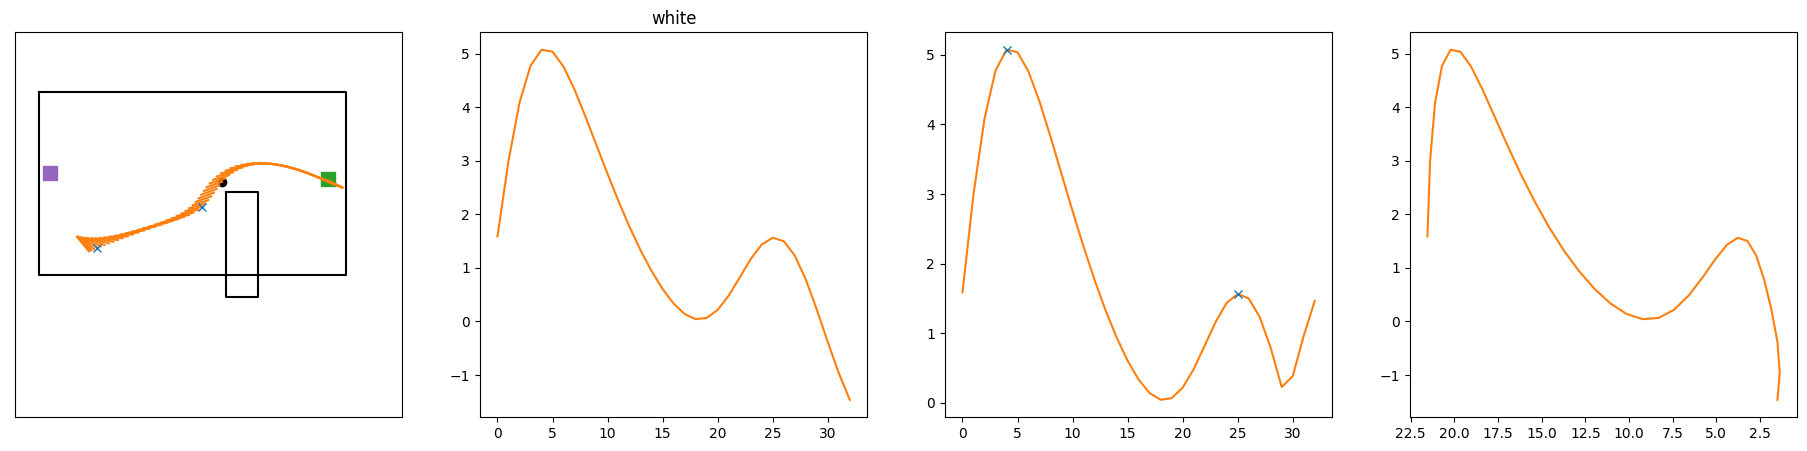

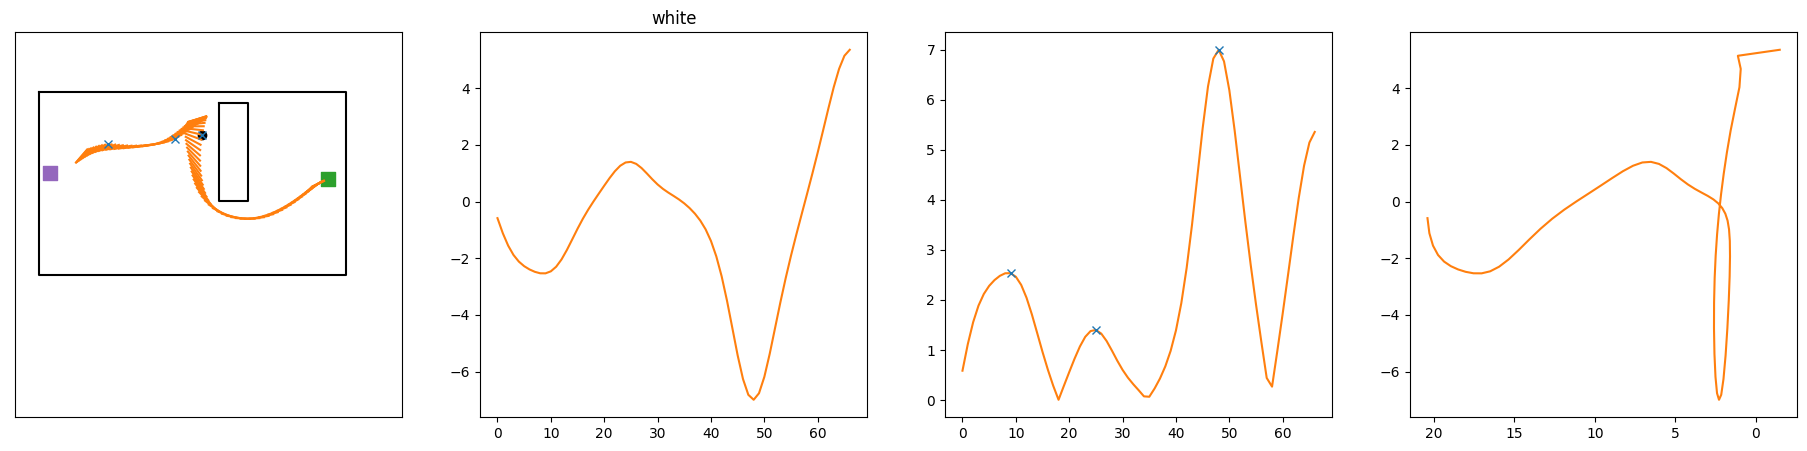

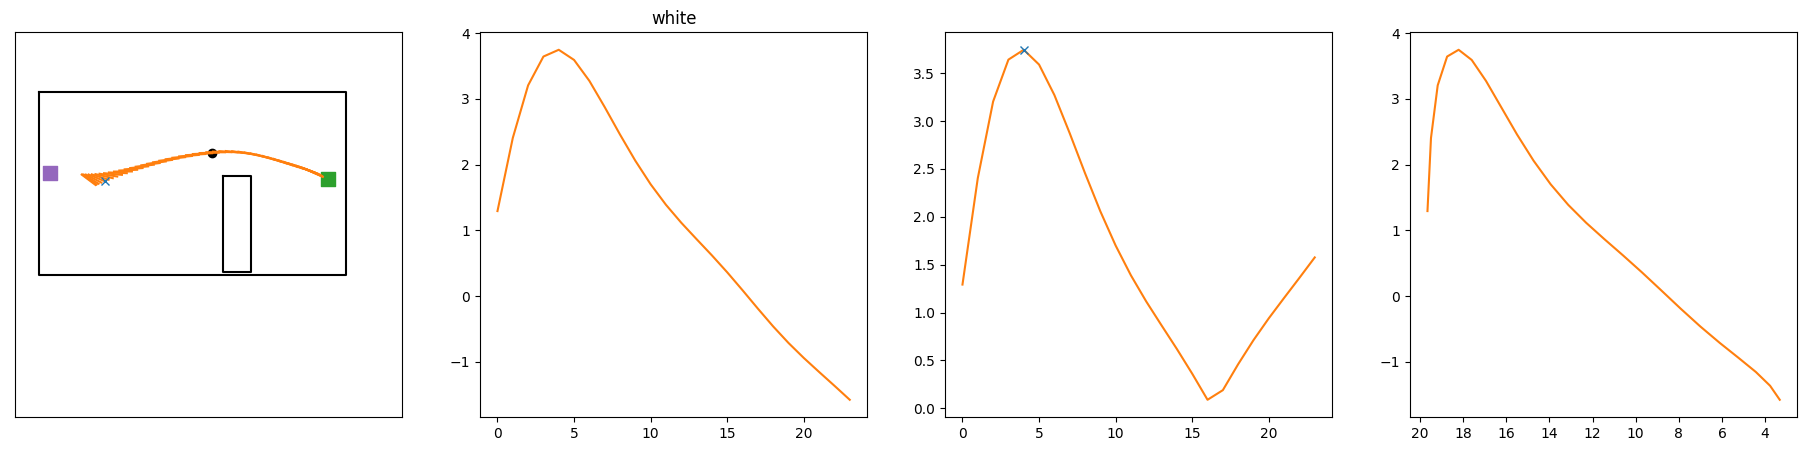

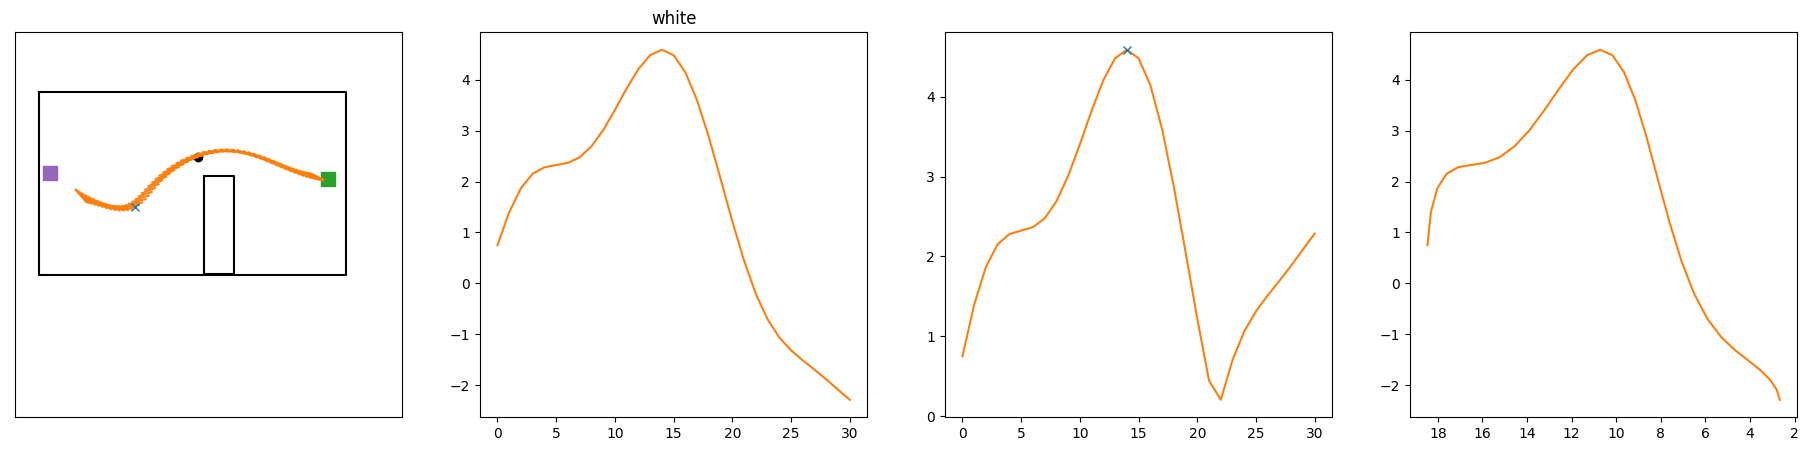

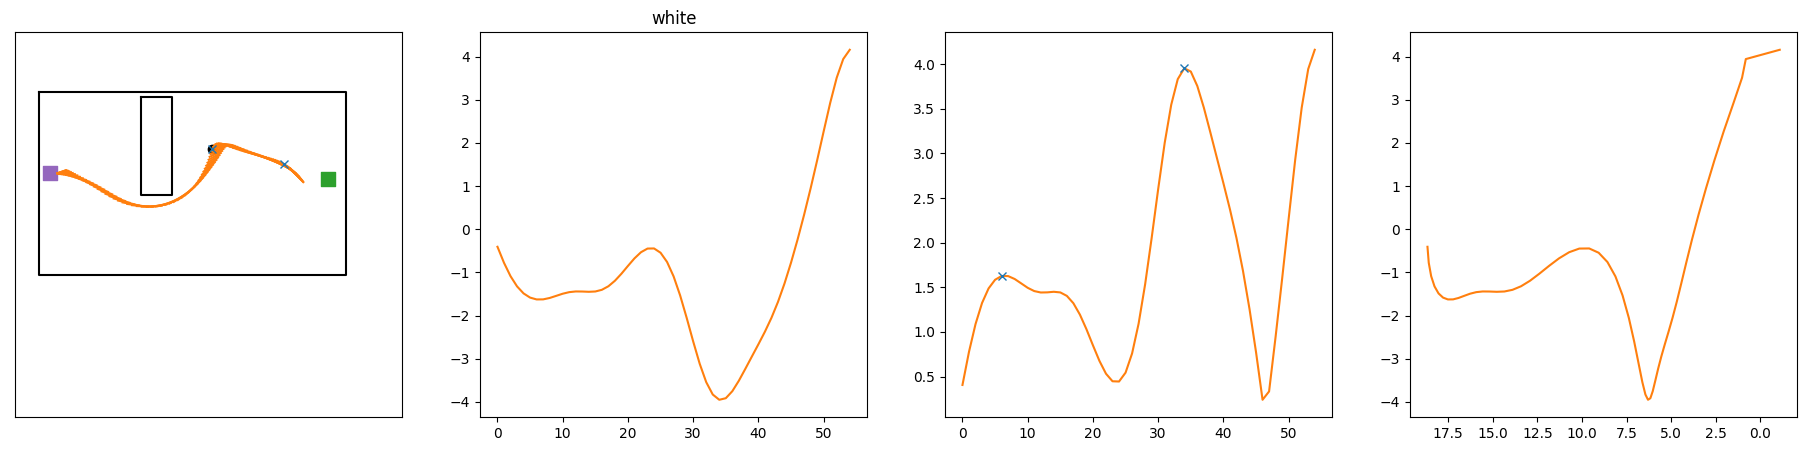

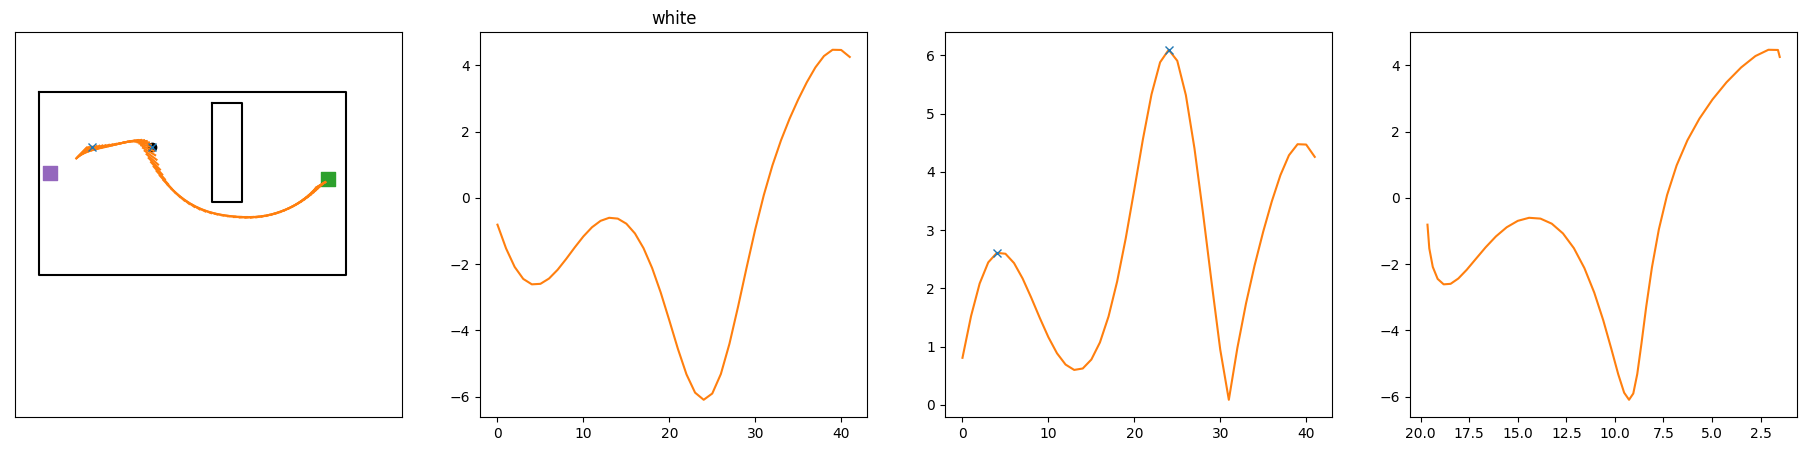

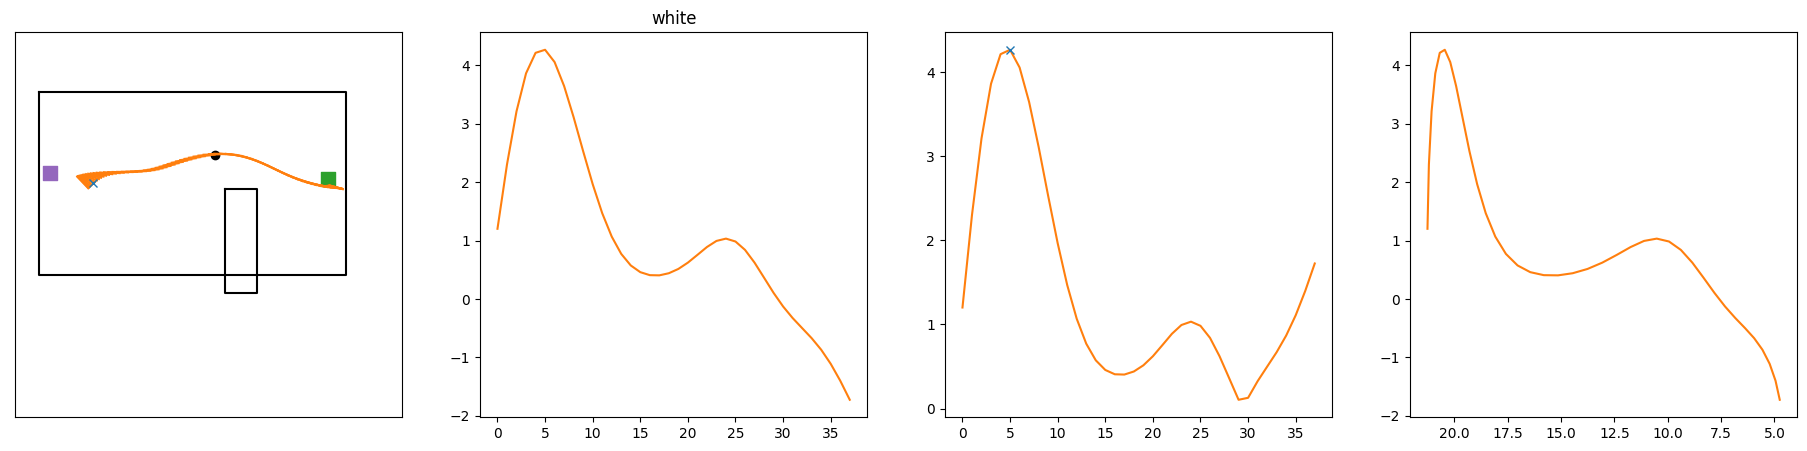

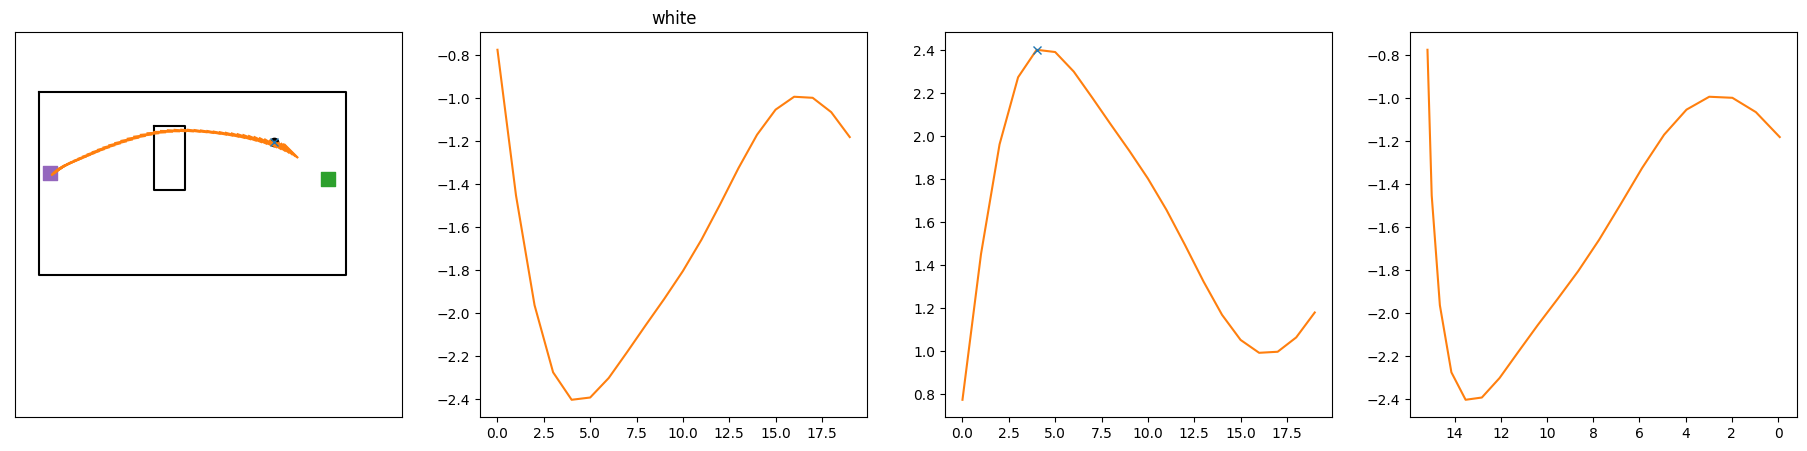

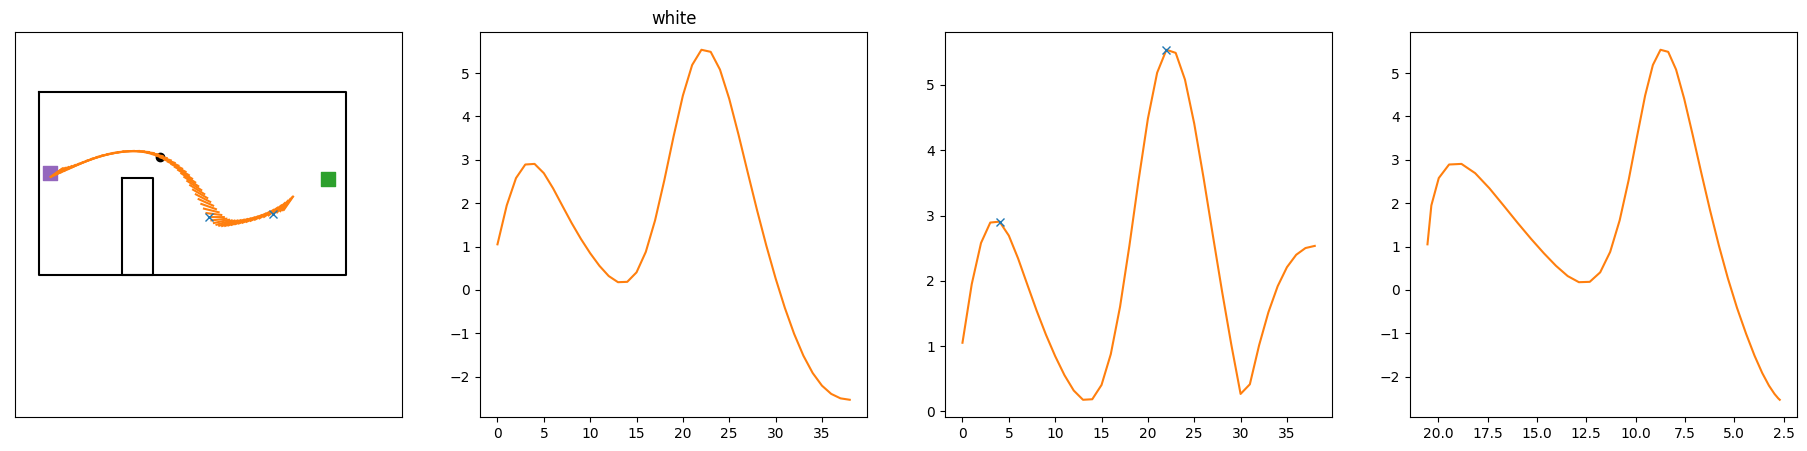

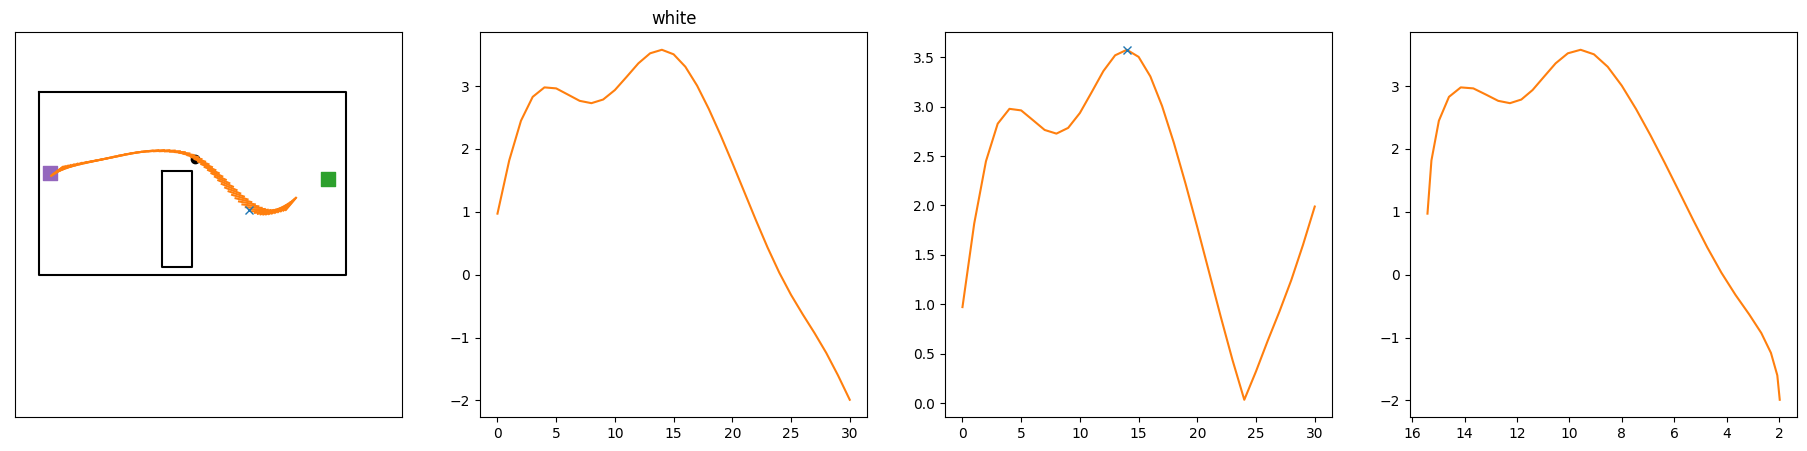

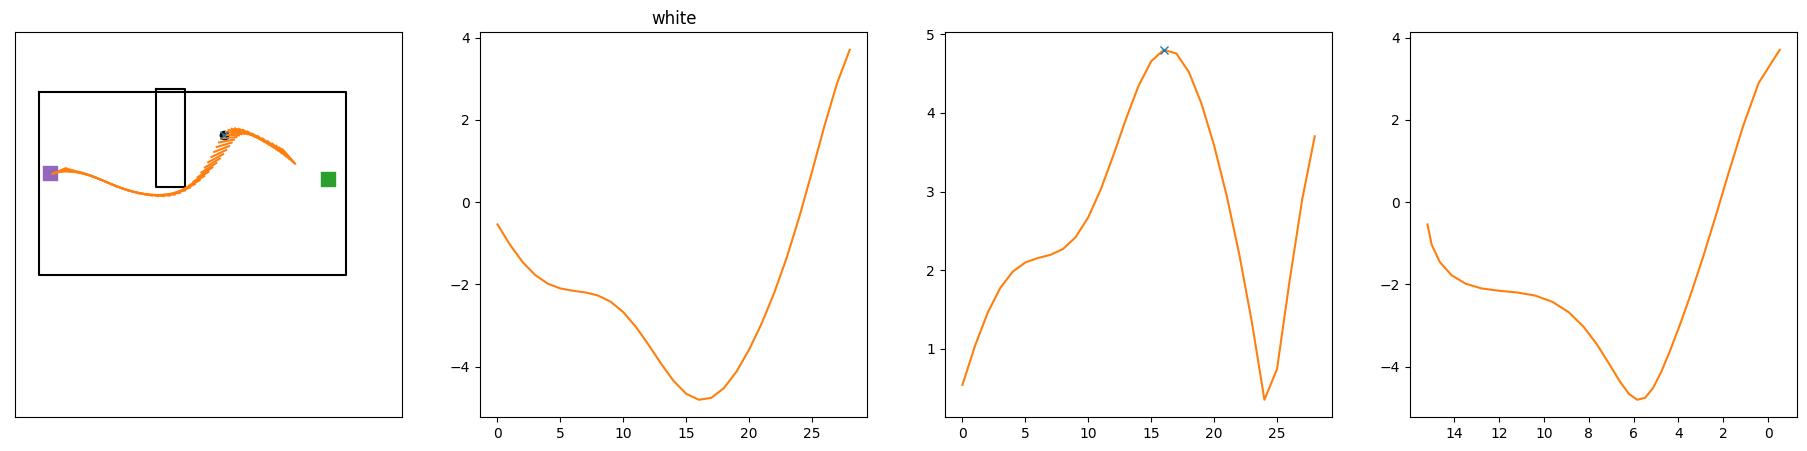

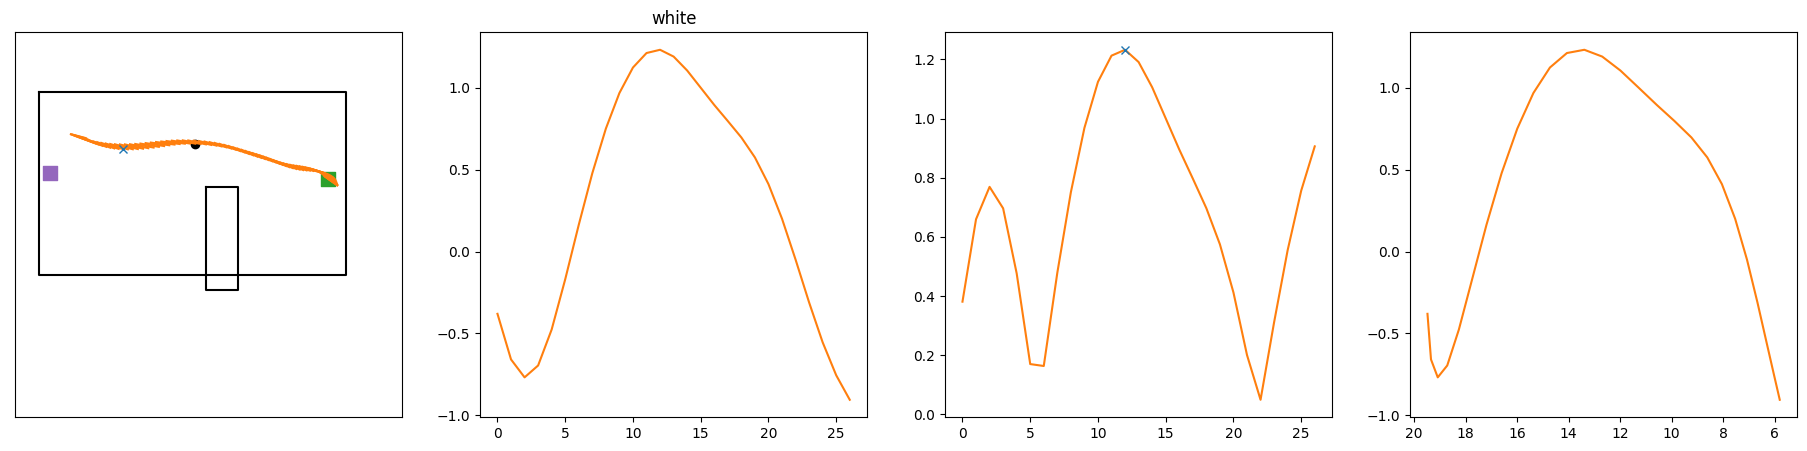

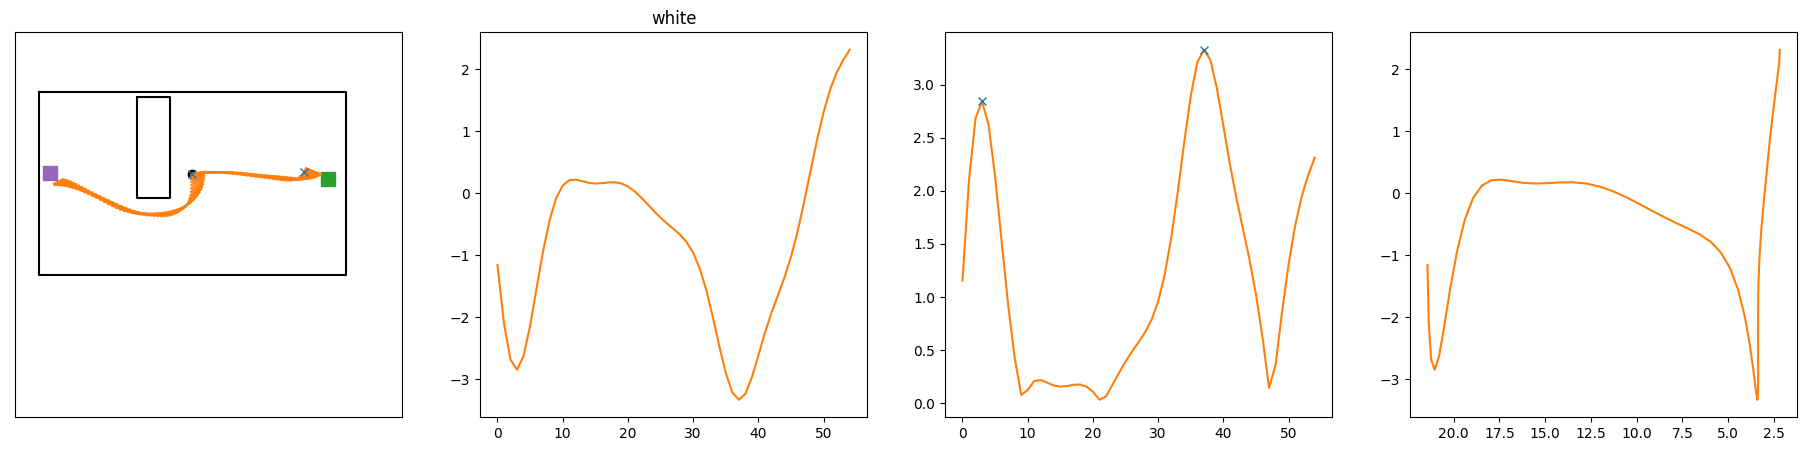

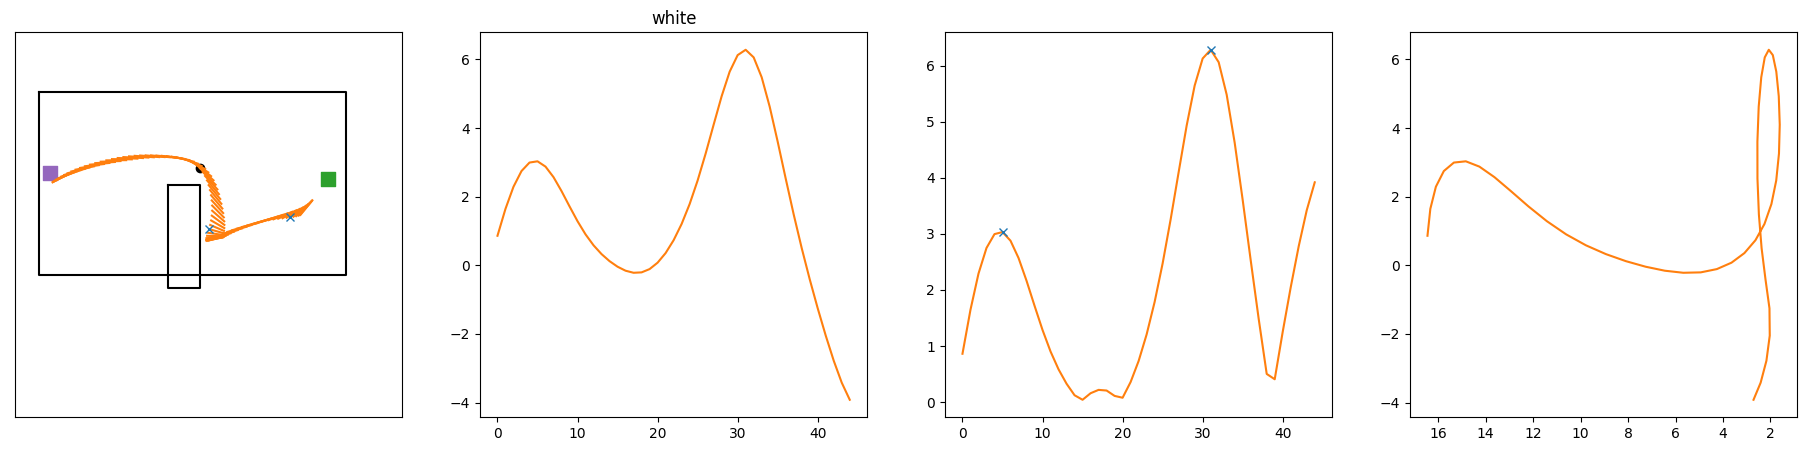

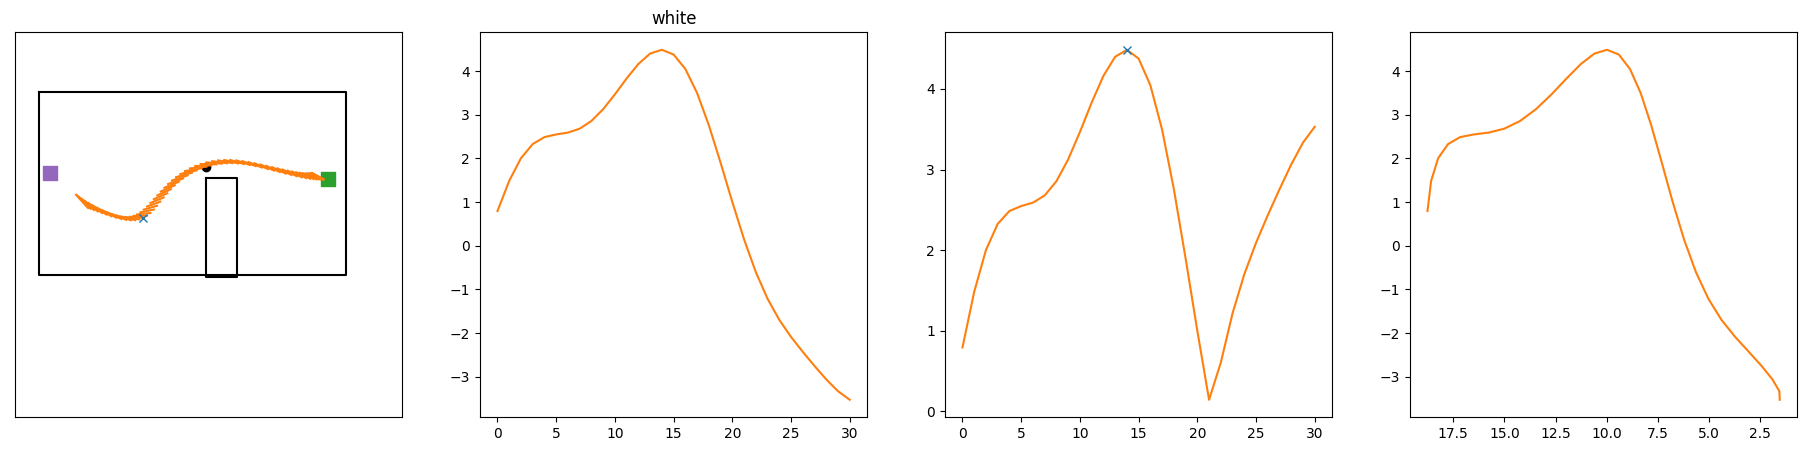

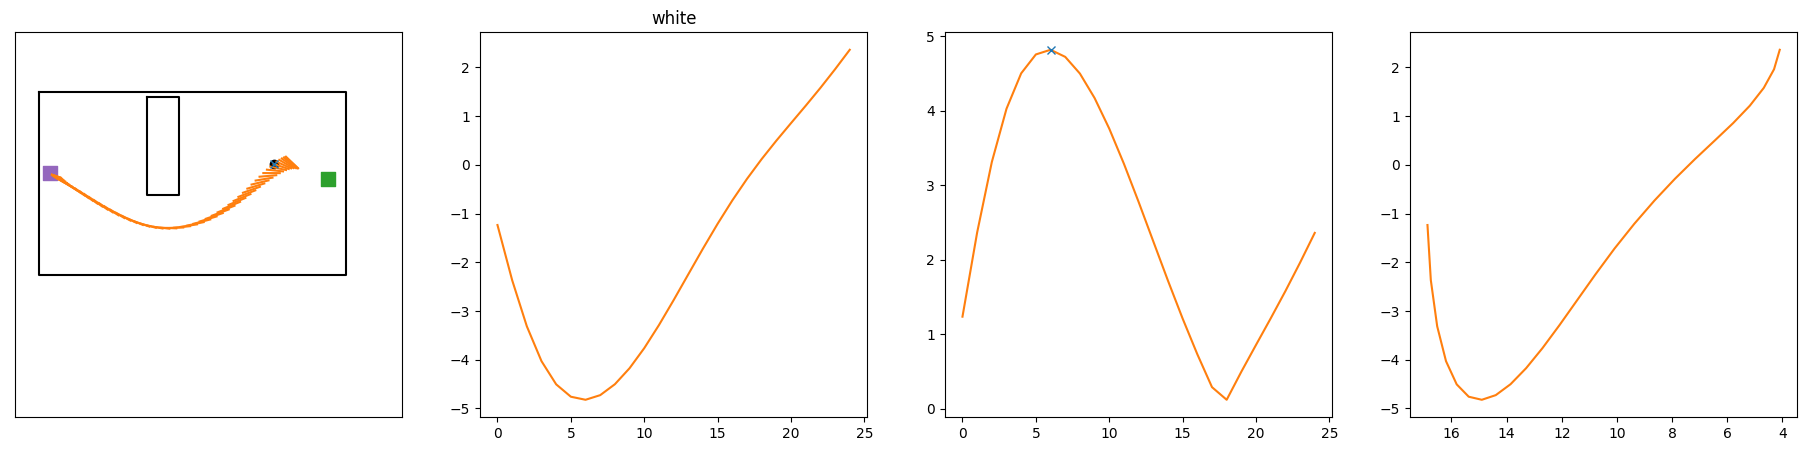

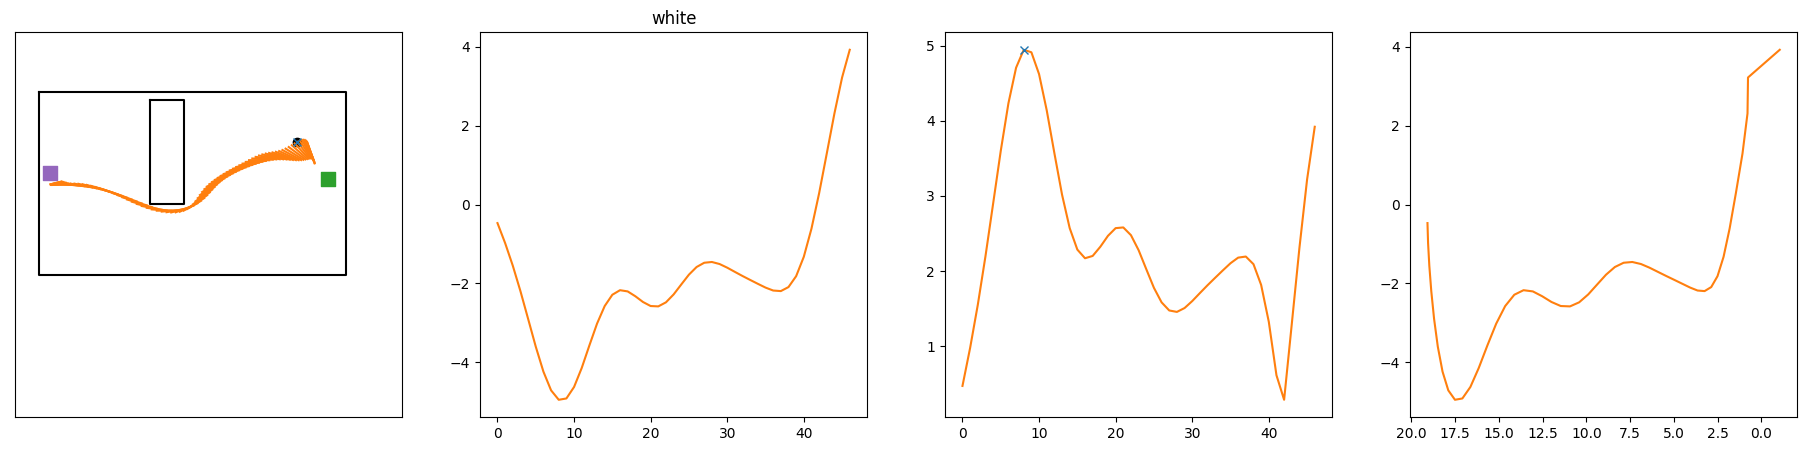

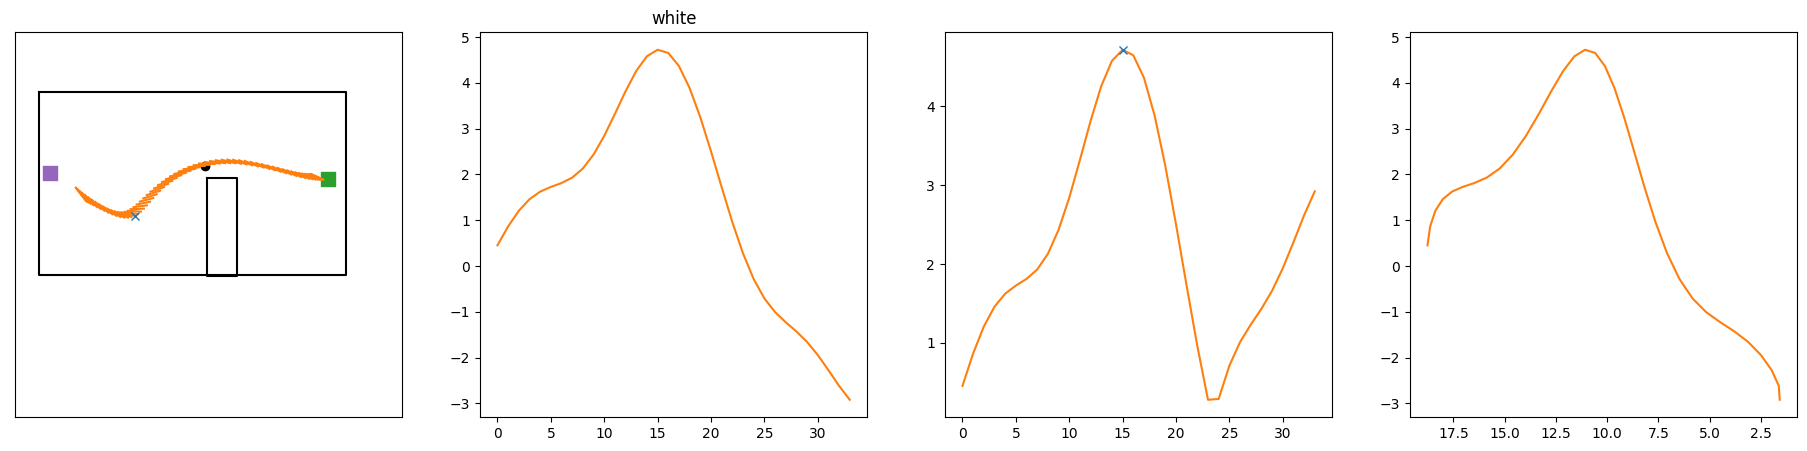

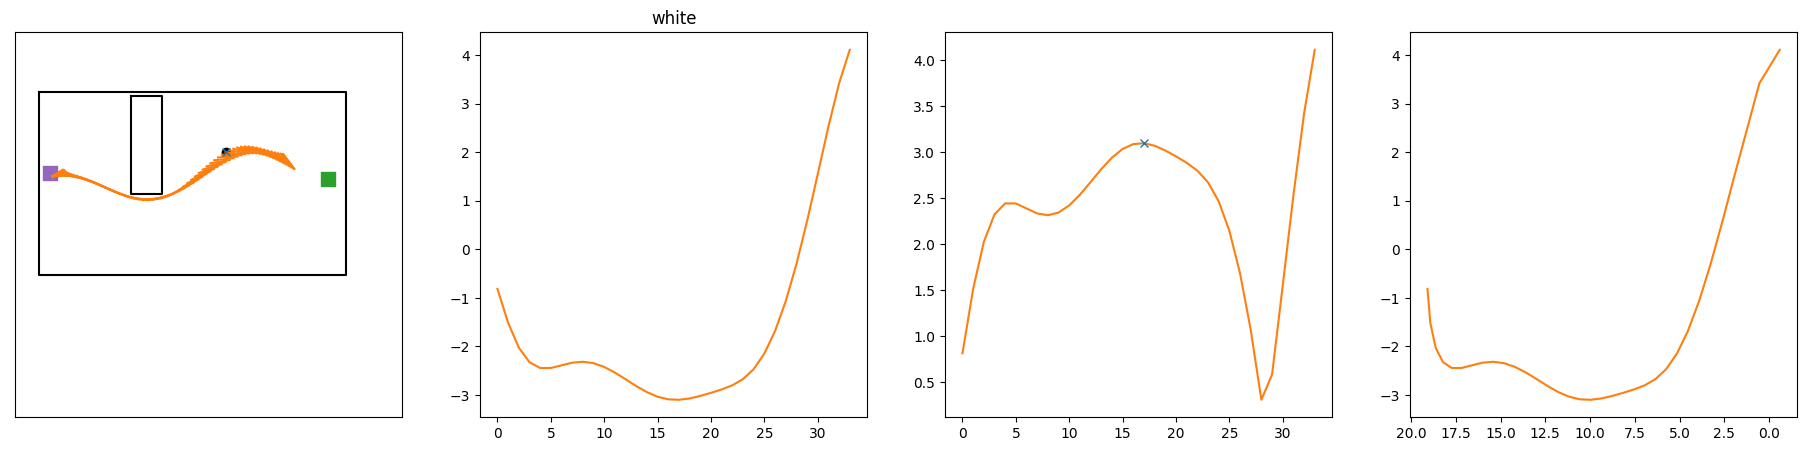

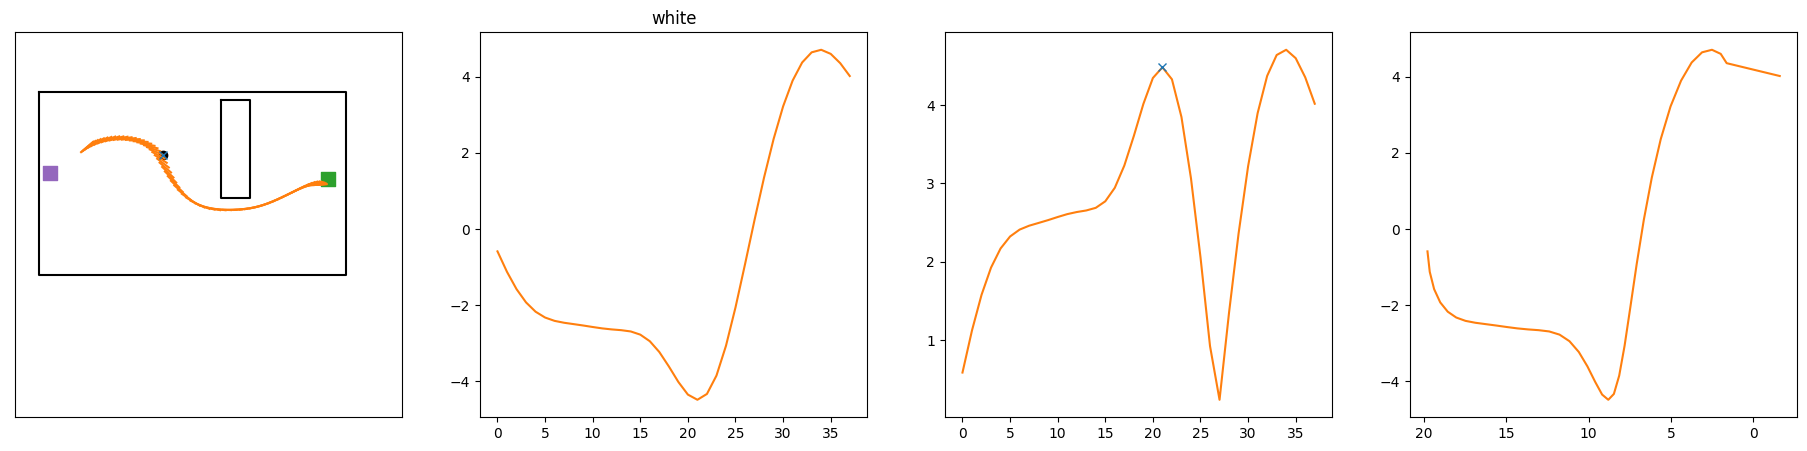

In [158]:
test = con0_long_nostart[(con0_long_nostart.turn_to_obstacle=='towards') & (con0_long_nostart.obstacle=='white')].sample(20)

for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,4,figsize=(23,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[3].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title(str(row.obstacle))

   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[3].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = row.head_angle_velocity[:int(row.obstacle_ind)].argmin()
    thresh_ind = np.argwhere(row.head_angle_velocity[:int(row.obstacle_ind)] == row.head_angle_velocity[:int(row.obstacle_ind)][thresh])[0][0]
    #ax[1].scatter(thresh_ind,row.head_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    #ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.head_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    ax[2].plot(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]),color = 'tab:orange')
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(1,12),prominence=1)
    ax[2].plot(peaks, np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[peaks], "x")
    ax[0].plot(row.ts_nose_x_cm[peaks], row.ts_nose_y_cm[peaks],"x")

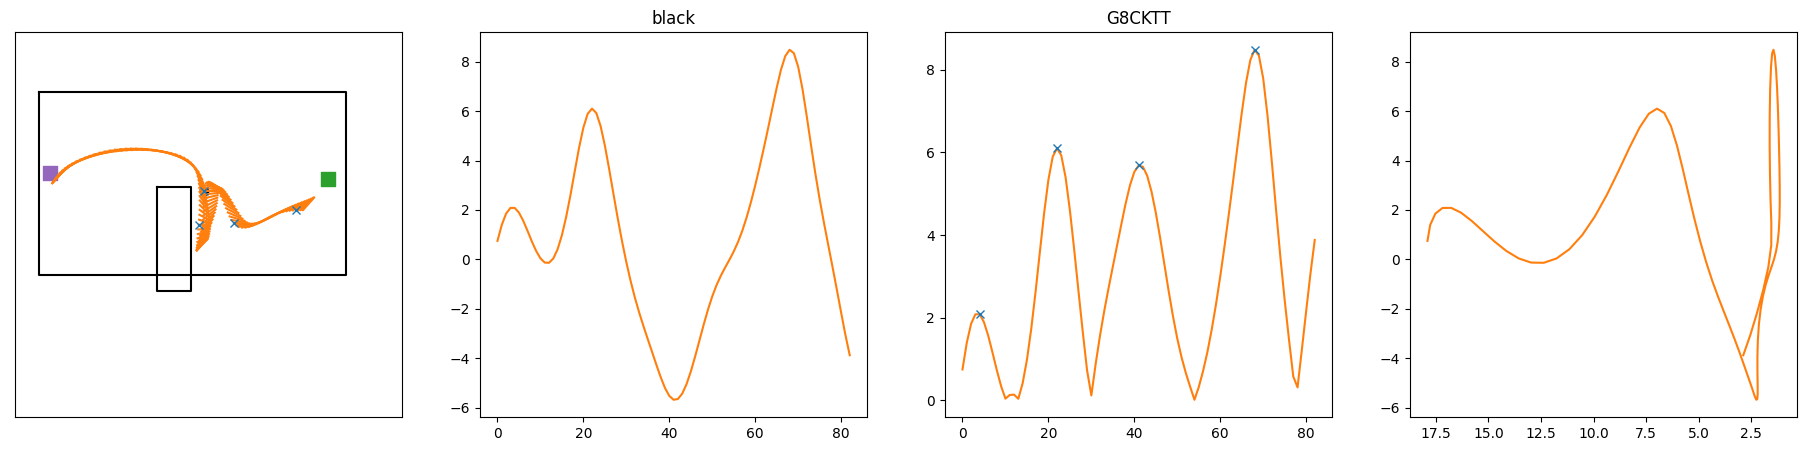

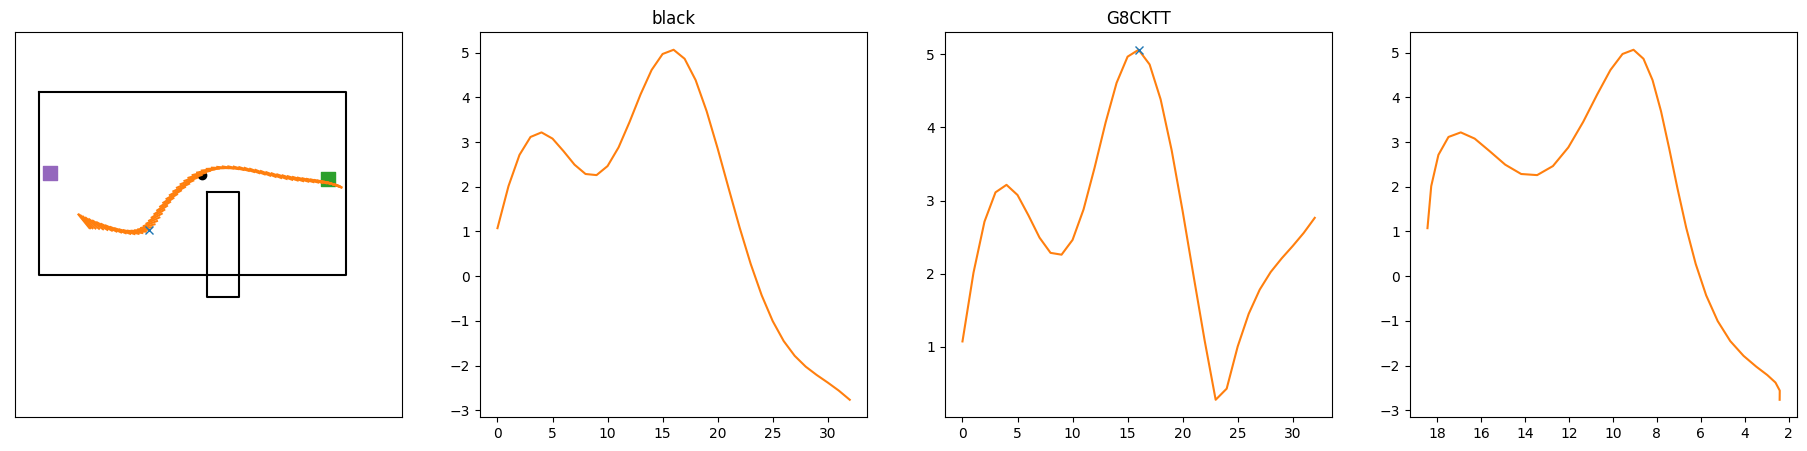

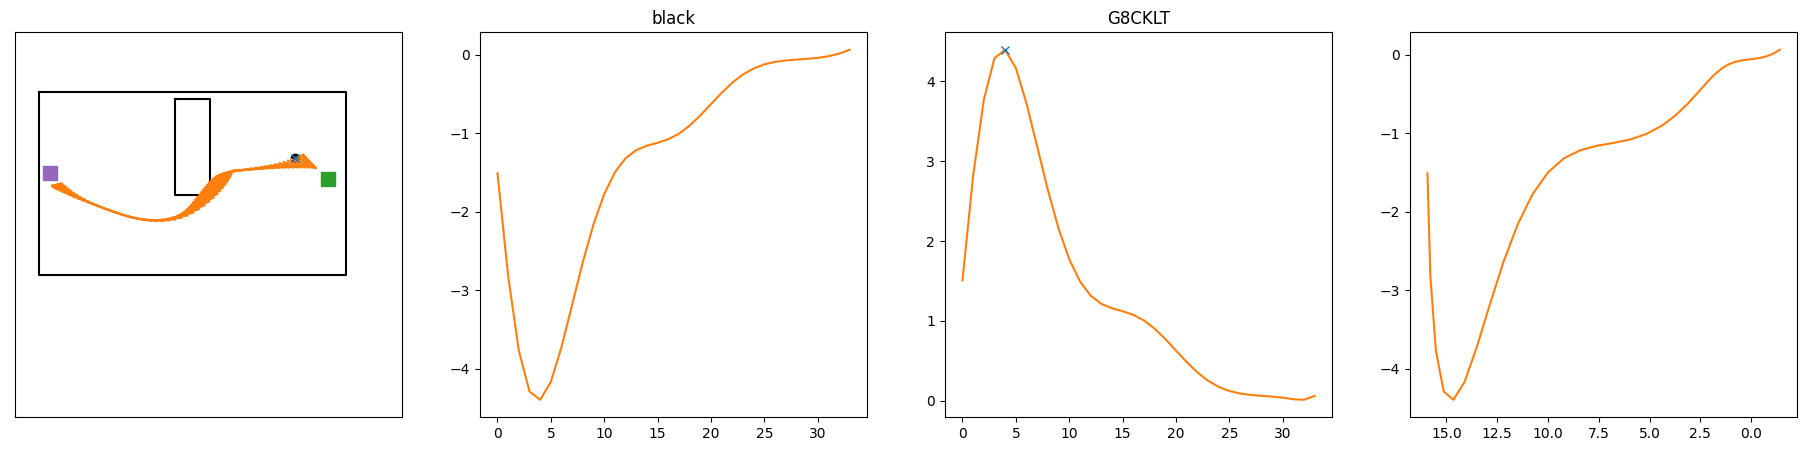

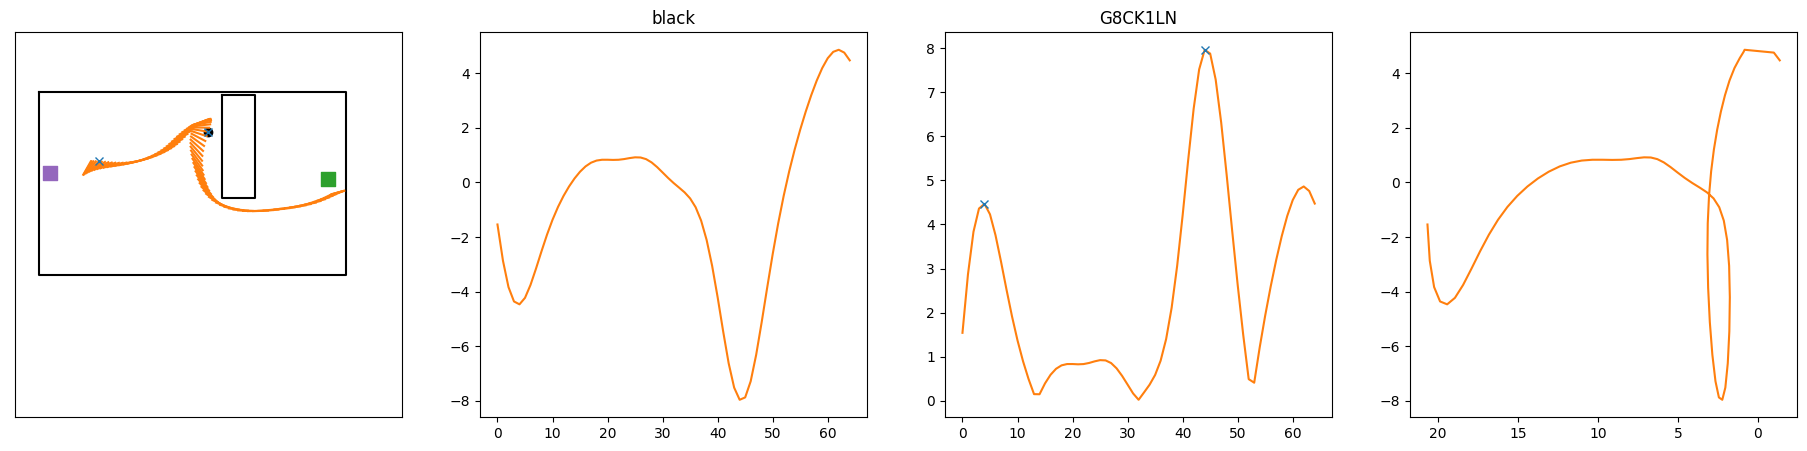

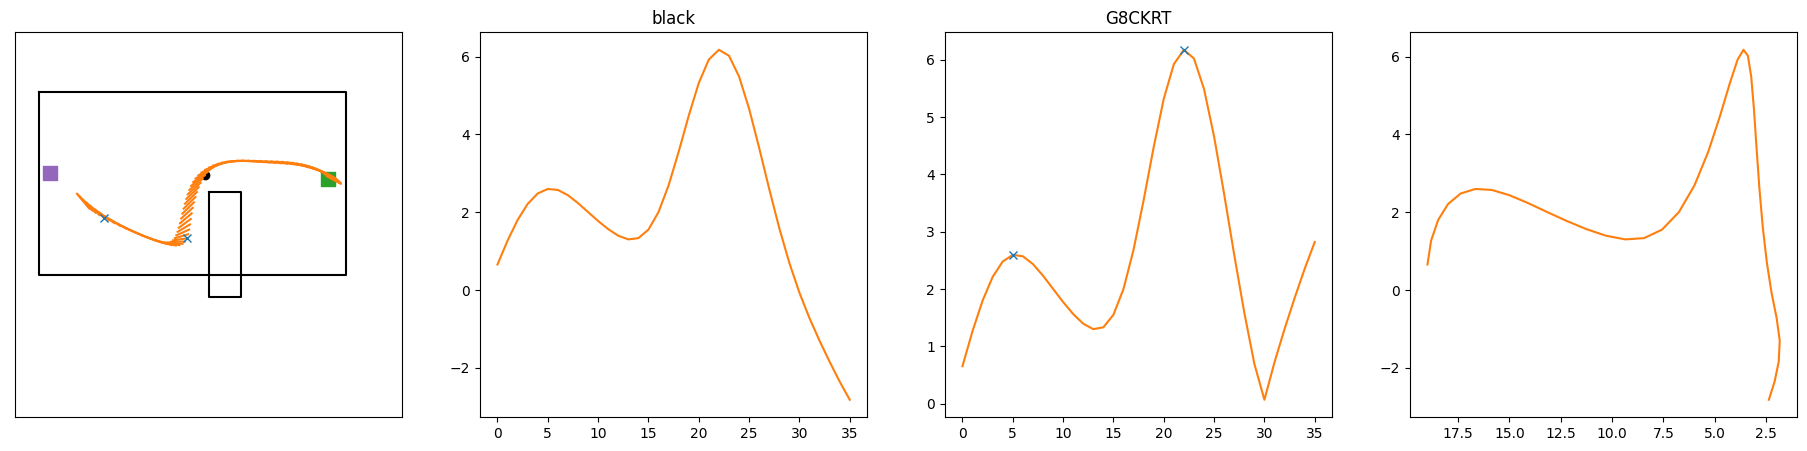

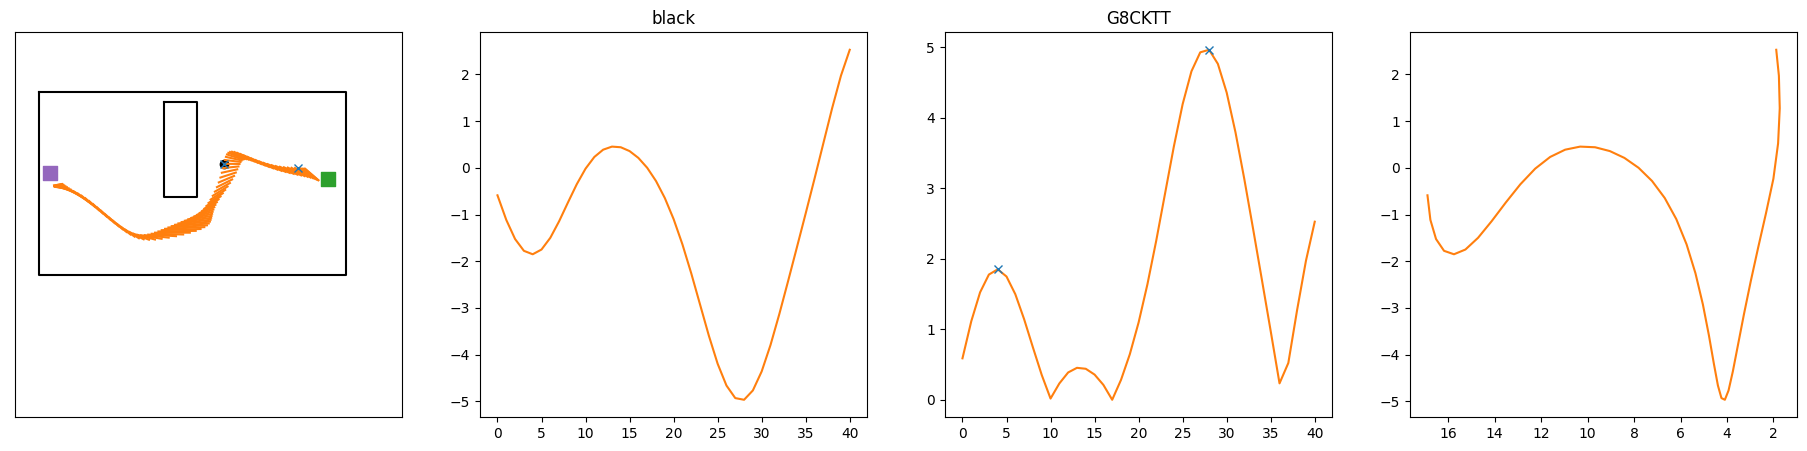

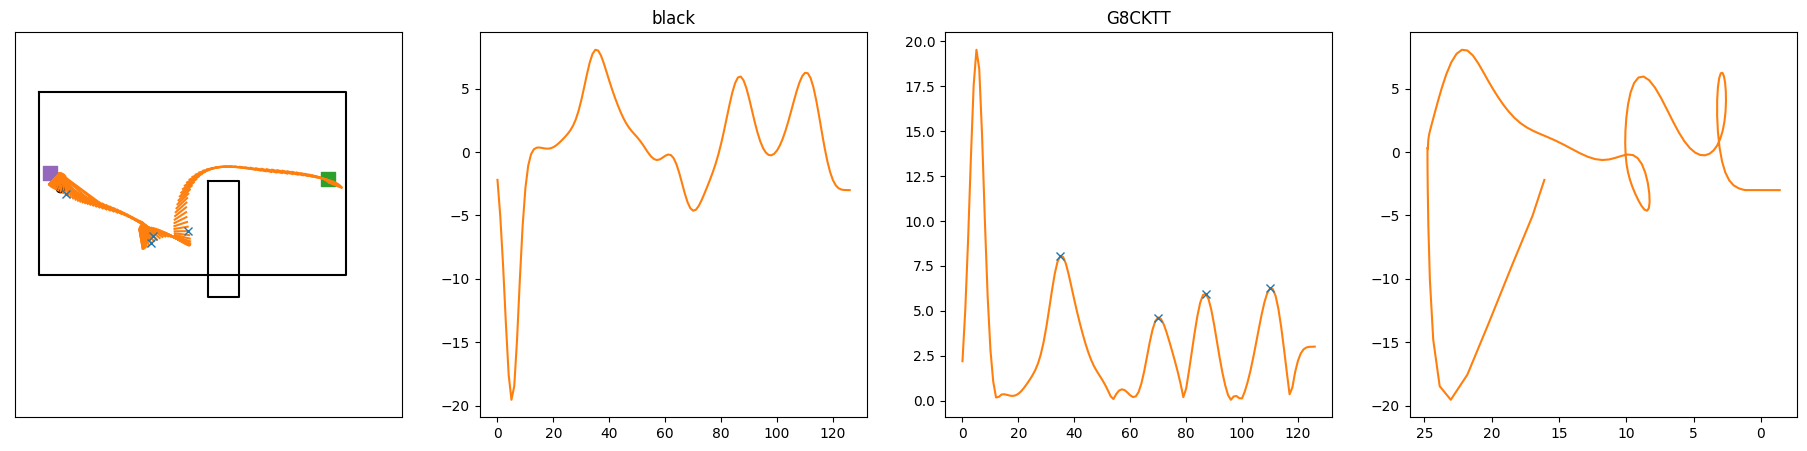

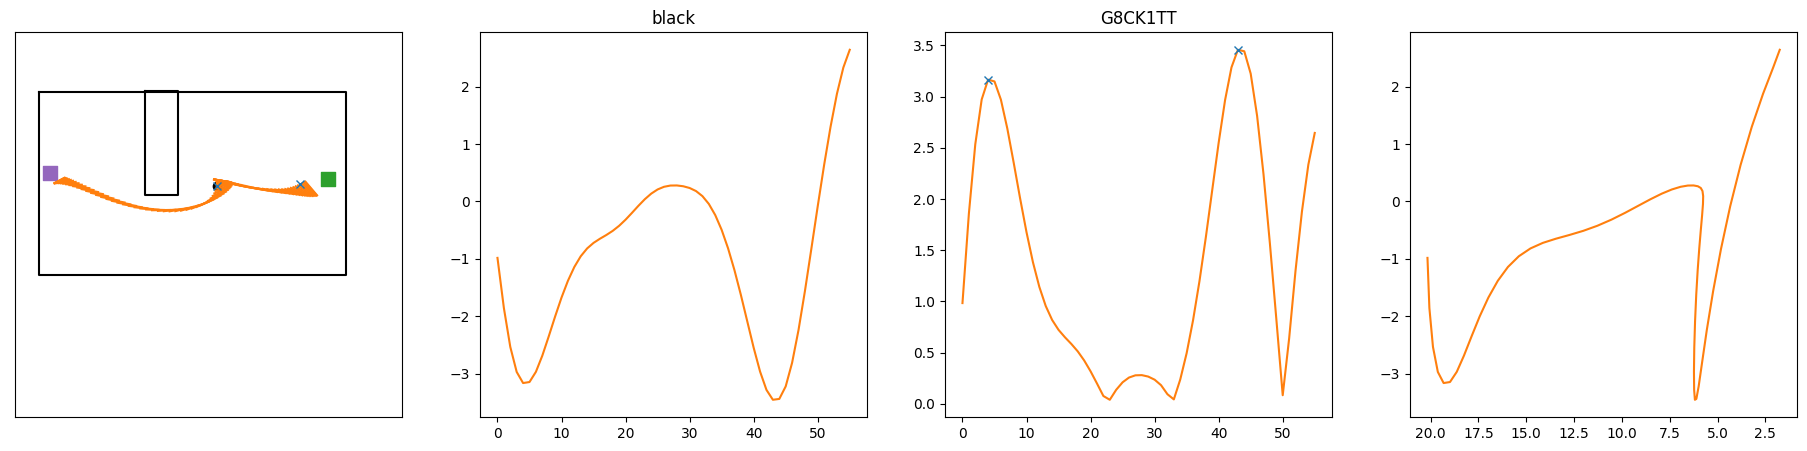

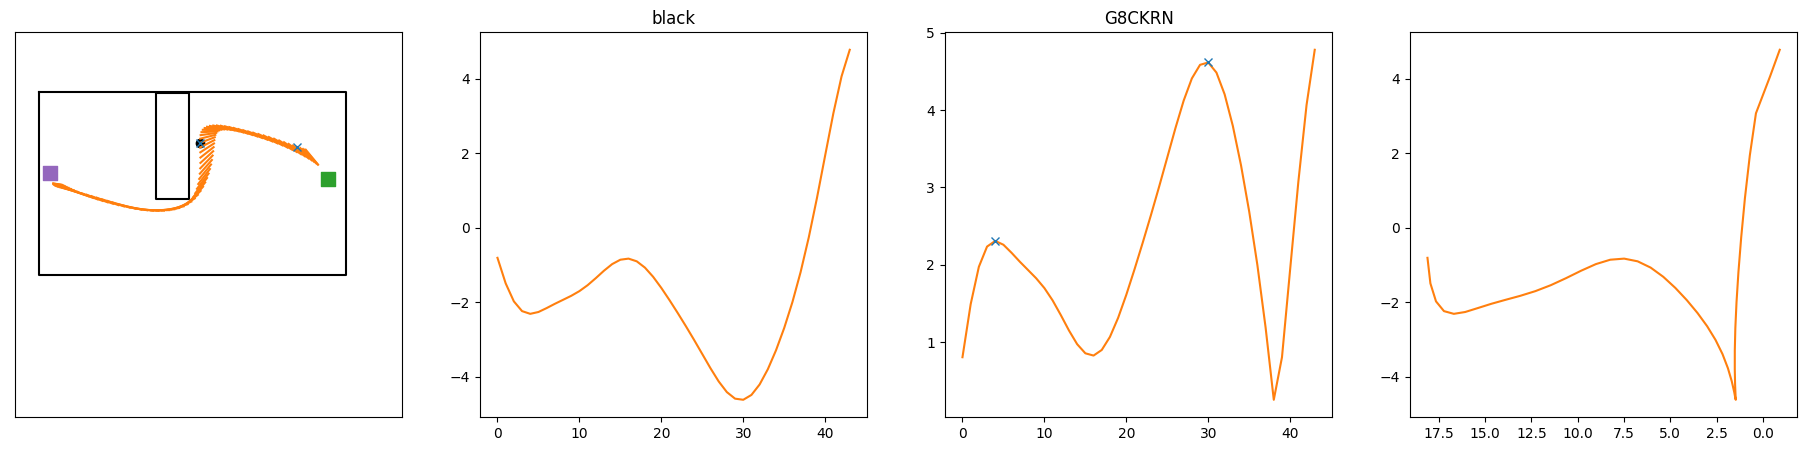

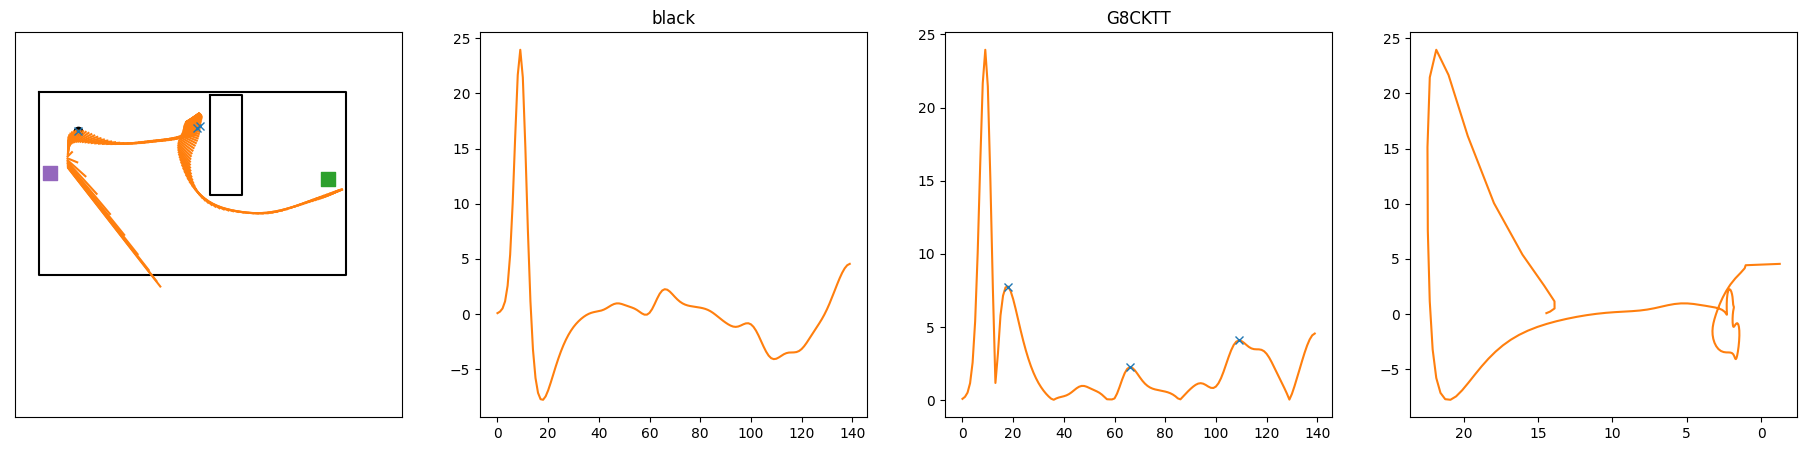

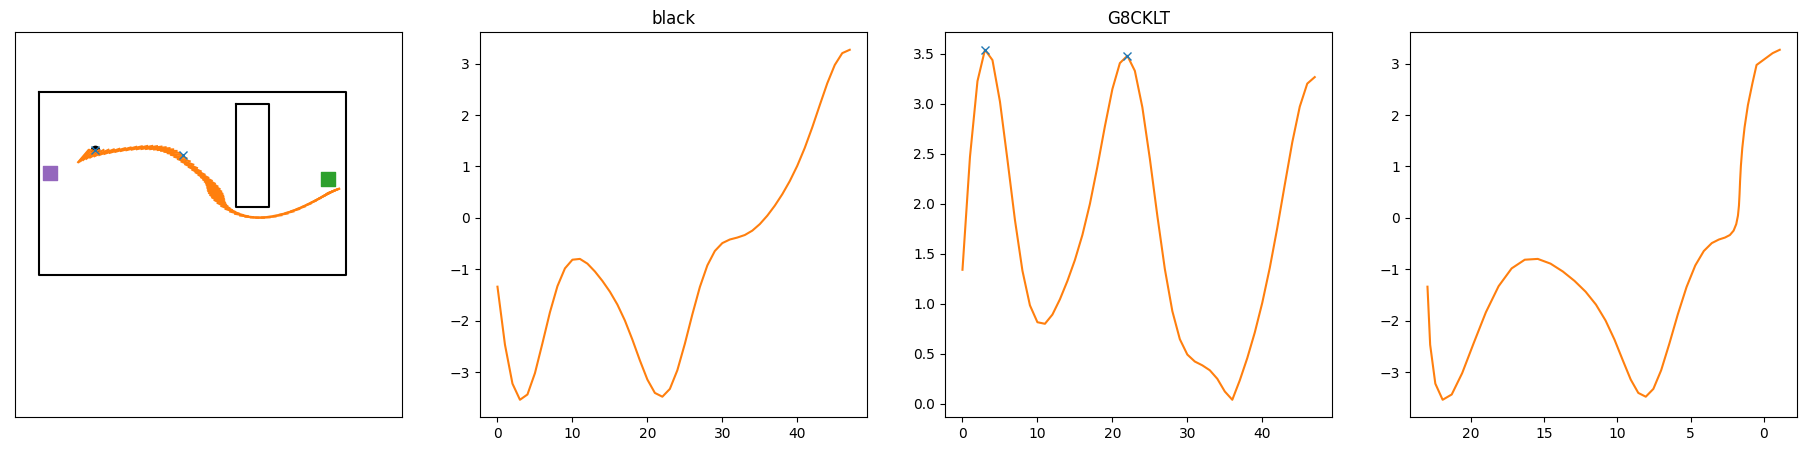

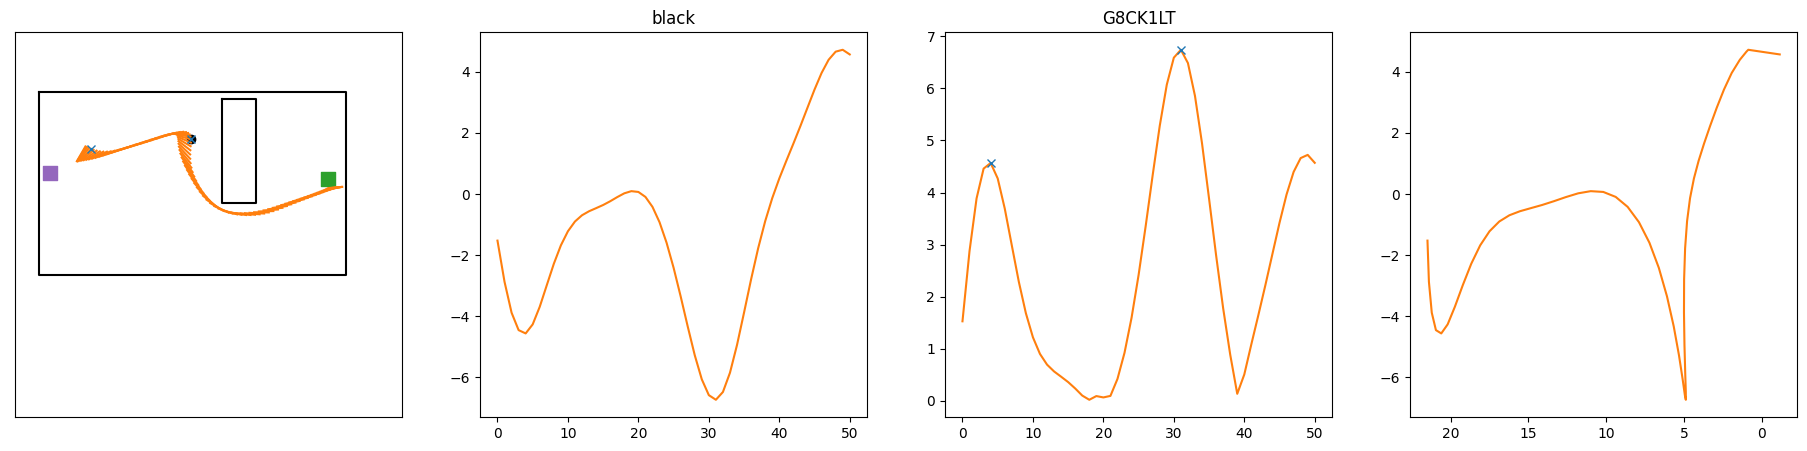

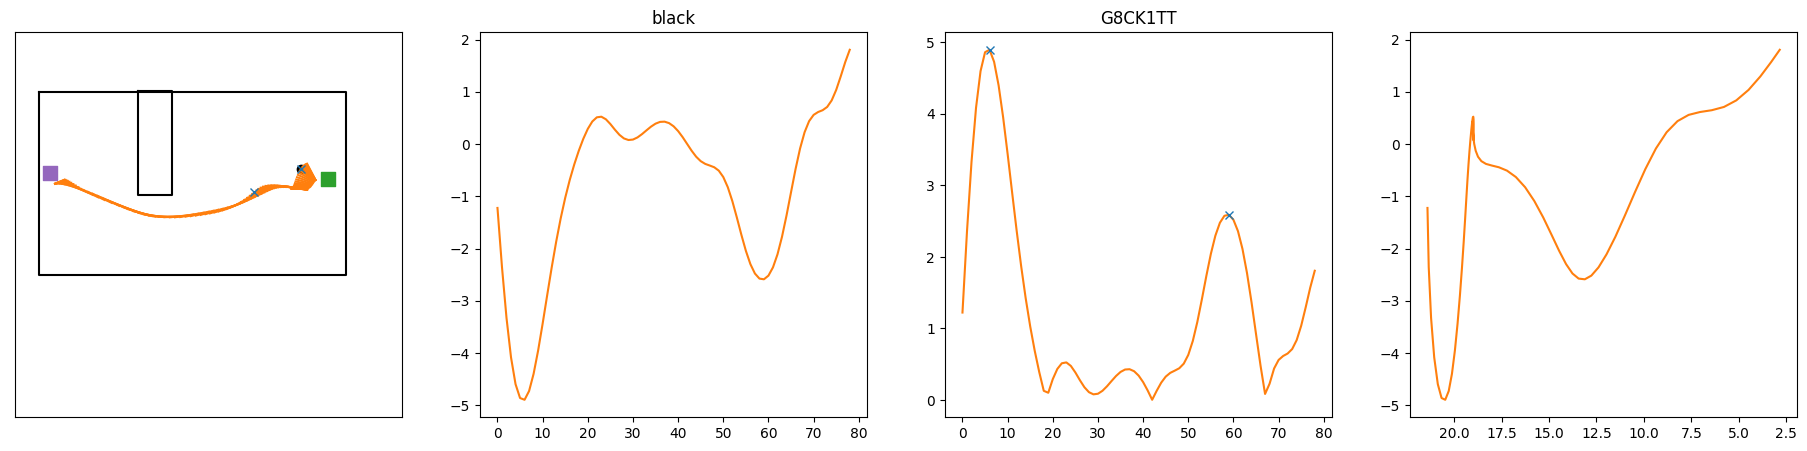

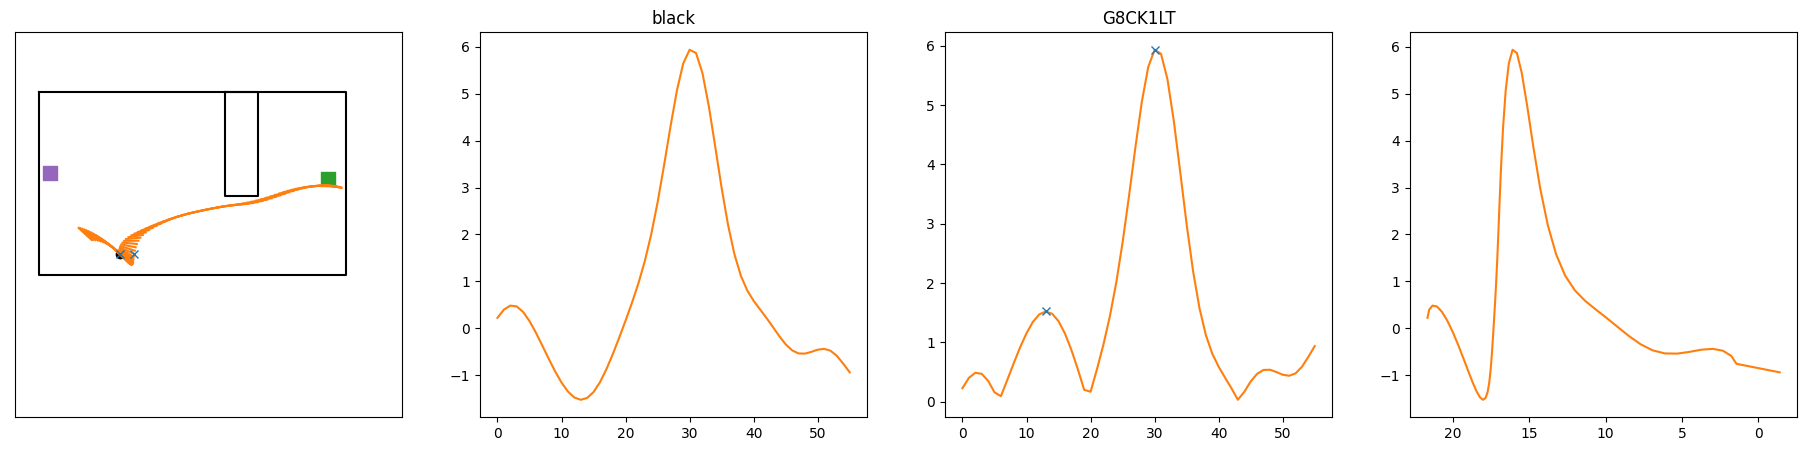

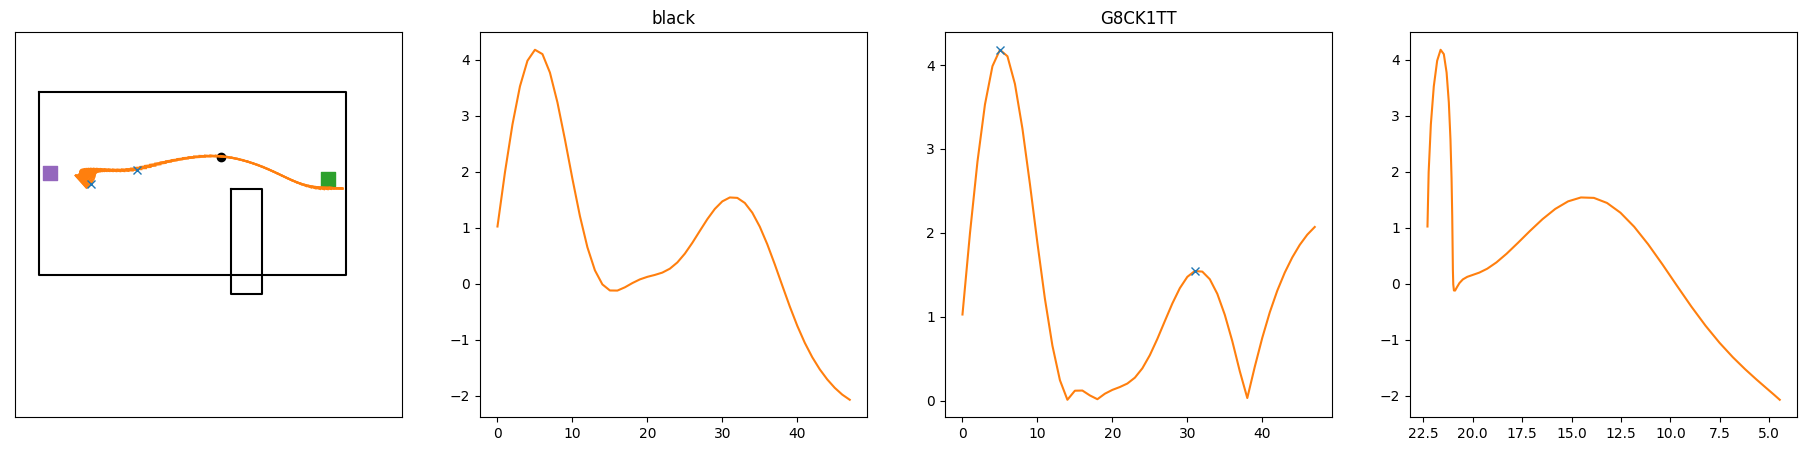

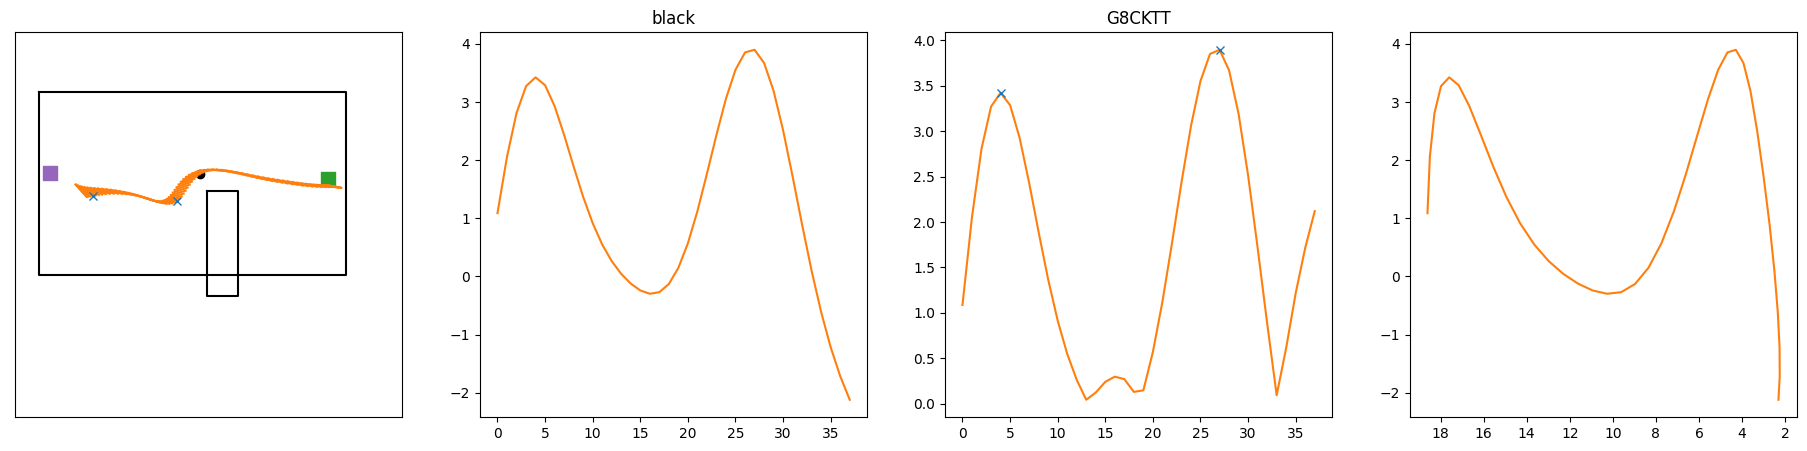

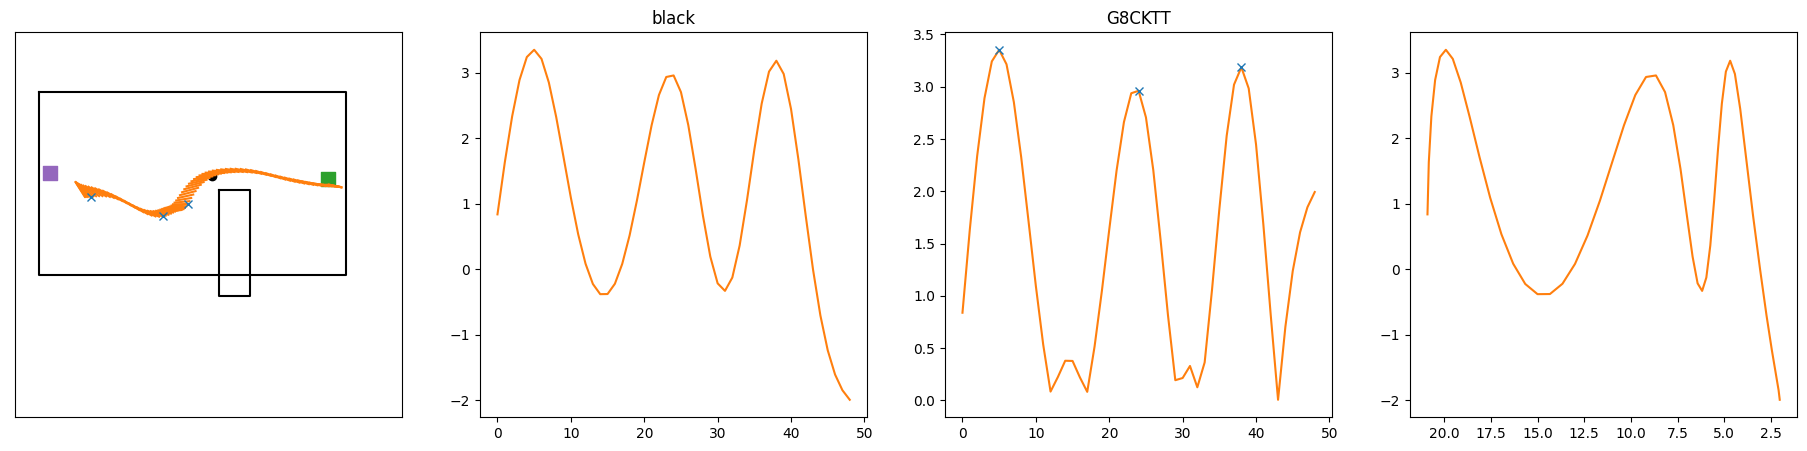

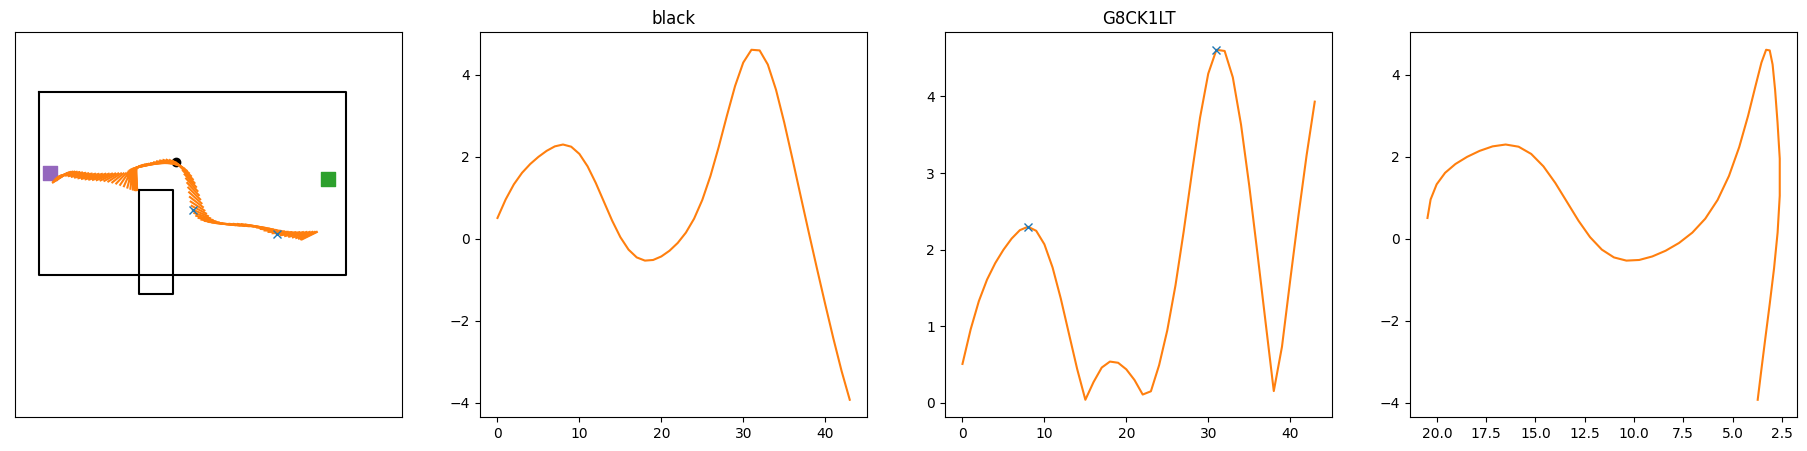

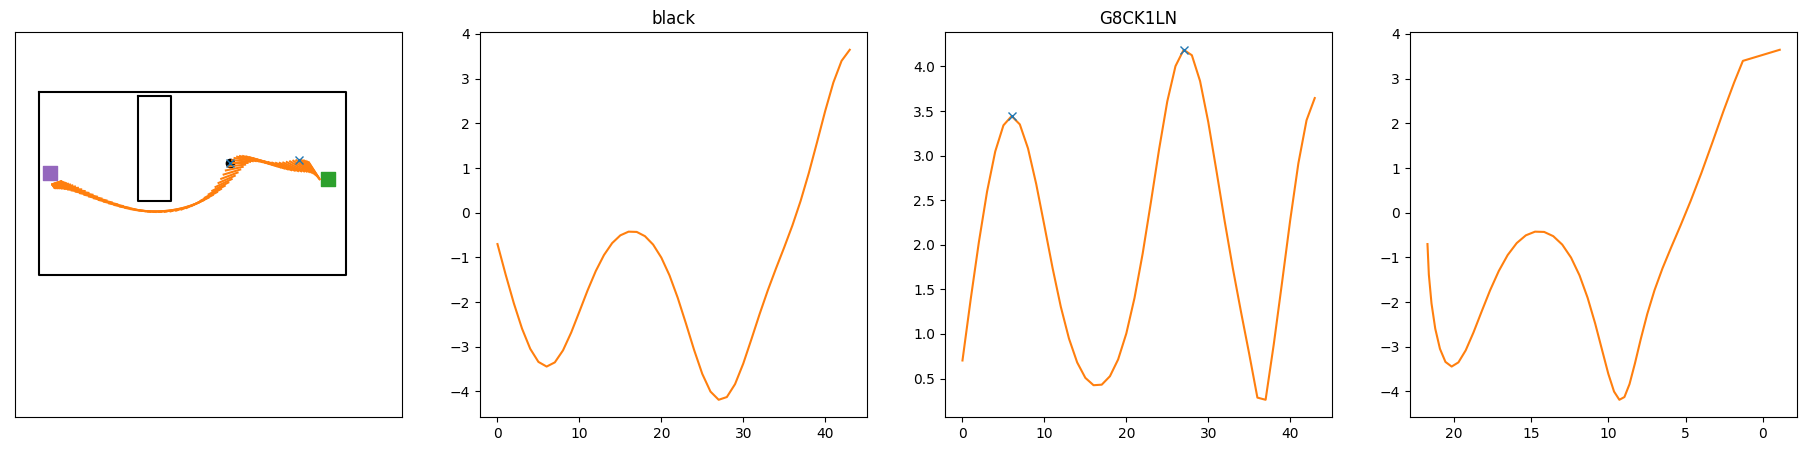

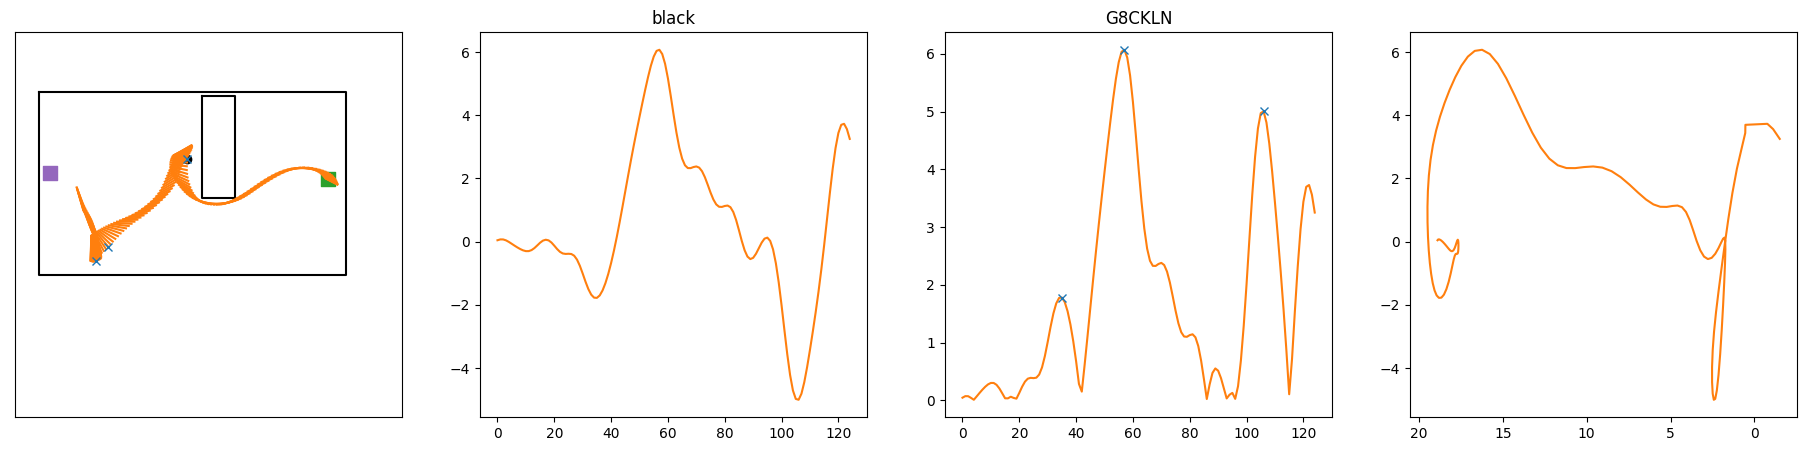

In [161]:
test = con0_long_nostart[(con0_long_nostart.turn_to_obstacle=='towards') & (con0_long_nostart.wall=='black')].sample(20)

for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,4,figsize=(23,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[3].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title(str(row.wall))
    ax[2].set_title(str(row.animal))

   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[3].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = row.head_angle_velocity[:int(row.obstacle_ind)].argmin()
    thresh_ind = np.argwhere(row.head_angle_velocity[:int(row.obstacle_ind)] == row.head_angle_velocity[:int(row.obstacle_ind)][thresh])[0][0]
    #ax[1].scatter(thresh_ind,row.head_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    #ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.head_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    ax[2].plot(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]),color = 'tab:orange')
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(1,12),prominence=1)
    ax[2].plot(peaks, np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[peaks], "x")
    ax[0].plot(row.ts_nose_x_cm[peaks], row.ts_nose_y_cm[peaks],"x")